In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Comment3

In [ ]:
# =====================================================================================
# THRESHOLD SENSITIVITY ANALYSIS  (Reviewer #2, Concern #3)  -- Colab, plain Python
#   Compares adjusted-p cut-offs (0.05 vs 0.08) and Fisher-score cut-offs (Top 500/800/1000):
#   gene-level overlap, effect directions, rank correlations and pathway stability (KEGG, WikiPathways)
# =====================================================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr, hypergeom
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "Threshold_Sensitivity_Reviewer3/"; os.makedirs(OUT, exist_ok=True)
DS = {"MDD": "GSE98793", "PTSD": "GSE63878"}
THR = ["0.05", "0.08"]; TOPS = [500, 800, 1000]; MAIN = ("0.08", 800)
SCORE = lambda t, g: ROOT + f"process_datasets_{t}/score/{g}_matrix_Transpose_labeled_Fisher_Scores.csv"
DATA  = lambda t, g: ROOT + f"process_datasets_{t}/datasets/{g}_matrix_Transpose_labeled.csv"
LIBDIR = ROOT + "Enrichment_Reviewer12/libraries/"
LIBS = ["KEGG_2021_Human", "WikiPathways_2024_Human"]
UNIV_FILES = [ROOT + "Final_validation/GSE98793_matrix_Transpose_labeled.csv", ROOT + "Final_validation/GSE63878_matrix_Transpose_labeled.csv"]
# Hub genes reported in Table 2 for the Top-800 analyses (from the STRING/CytoHubba step)
HUB = {("0.08", 800): ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"],
       ("0.05", 800): ["DOCK4", "EIF4B", "RPS6", "RPS19", "EEF2", "RPS28", "RPS6KB2", "RPS10", "RPL15", "RPS10-NUDT3"]}
SEEDS = ["IGF1R", "STAT2", "HGF", "PML"]

# ------------------------------------------------------------------ 1. Fisher-score lists
F = {}
for t in THR:
    for dis, g in DS.items():
        s = pd.read_csv(SCORE(t, g)).sort_values("Fisher Score", ascending=False).reset_index(drop=True)
        s["Rank"] = np.arange(1, len(s) + 1); F[(t, dis)] = s
top = lambda t, dis, n: list(F[(t, dis)].Feature.head(n))
shared = {(t, n): sorted(set(top(t, "MDD", n)) & set(top(t, "PTSD", n))) for t in THR for n in TOPS}
REF = set(shared[MAIN])

rows = []
for t in THR:
    for n in TOPS:
        s = set(shared[(t, n)]); hub = HUB.get((t, n))
        rows.append({"Adjusted p cut-off": t, "Fisher top-N": n,
                     "DEGs MDD": len(F[(t, "MDD")]), "DEGs PTSD": len(F[(t, "PTSD")]),
                     "Genes used MDD": min(n, len(F[(t, "MDD")])), "Genes used PTSD": min(n, len(F[(t, "PTSD")])),
                     "Mean Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).mean():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).mean():.4f}",
                     "Median Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).median():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).median():.4f}",
                     "Shared genes": len(s), "Overlap with main 19": len(s & REF),
                     "Jaccard vs main": round(len(s & REF) / len(s | REF), 2) if s | REF else np.nan,
                     "Seed genes retained": ", ".join(g for g in SEEDS if g in s) or "none",
                     "Shared genes list": ", ".join(sorted(s)),
                     "Hub genes (Table 2)": ", ".join(hub) if hub else "not computed",
                     "Hub overlap with main": (len(set(hub) & set(HUB[MAIN])) if hub else np.nan)})
grid = pd.DataFrame(rows); grid.to_csv(OUT + "Table2_revised_threshold_grid.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 2. Rank correlations
rc = []
for dis in DS:
    a, b = F[("0.05", dis)], F[("0.08", dis)]
    m = a.merge(b, on="Feature", suffixes=("_05", "_08"))
    rho, _ = spearmanr(m["Fisher Score_05"], m["Fisher Score_08"])
    for n in TOPS:
        A, B = set(top("0.05", dis, n)), set(top("0.08", dis, n))
        rc.append(dict(Comparison=f"{dis}: 0.05 vs 0.08", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                       Top_N=n, Top_N_overlap=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2)))
for t in THR:
    m = F[(t, "MDD")].merge(F[(t, "PTSD")], on="Feature", suffixes=("_MDD", "_PTSD"))
    rho, p = spearmanr(m["Fisher Score_MDD"], m["Fisher Score_PTSD"]) if len(m) > 2 else (np.nan, np.nan)
    rc.append(dict(Comparison=f"MDD vs PTSD at {t}", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                   Spearman_p=p, Top_N=np.nan, Top_N_overlap=np.nan, Jaccard=np.nan))
rc = pd.DataFrame(rc); rc.to_csv(OUT + "S_rank_correlations.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 3. Effect directions (log2 fold change)
def log2fc(path, genes):
    cols = pd.read_csv(path, nrows=0).columns
    use = [c for c in cols if re.sub(r"\.\d+$", "", c) in genes] + ["target"]
    df = pd.read_csv(path, usecols=use); y = df.pop("target").values == 1
    df.columns = [re.sub(r"\.\d+$", "", c) for c in df.columns]
    df = df.T.groupby(level=0).mean().T
    return (df[y].mean() - df[~y].mean())
union = sorted(set().union(*[set(v) for v in shared.values()]))
fc = {dis: log2fc(DATA("0.08", g), set(union)) for dis, g in DS.items()}
eff = pd.DataFrame({"Gene": union})
for dis in DS:
    eff[f"log2FC {dis}"] = eff.Gene.map(fc[dis]).round(3)
    eff[f"Direction {dis}"] = np.where(eff[f"log2FC {dis}"] > 0, "Up", "Down")
    for t in THR:
        r = F[(t, dis)].set_index("Feature")["Rank"]
        eff[f"Fisher rank {dis} {t}"] = eff.Gene.map(r).astype("Int64")
eff["Concordant direction"] = np.where(eff["Direction MDD"] == eff["Direction PTSD"], "yes", "no")
for t in THR:
    for n in TOPS:
        eff[f"Shared {t} Top{n}"] = eff.Gene.isin(shared[(t, n)]).map({True: "x", False: ""})
eff["Main 19"] = eff.Gene.isin(REF).map({True: "x", False: ""})
eff["Seed gene"] = eff.Gene.isin(SEEDS).map({True: "x", False: ""})
eff.to_csv(OUT + "S_gene_level_overlap_directions.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 4. Pathway stability (KEGG, WikiPathways)
def symbols(p):
    return {g for g in {re.sub(r"\.\d+$", "", c).strip() for c in pd.read_csv(p, nrows=0).columns if c != "target"} if g and "///" not in g}
U = set.intersection(*[symbols(p) for p in UNIV_FILES]); N = len(U)
def load_lib(name):
    lib = {}
    for line in open(LIBDIR + name + ".gmt"):
        parts = line.rstrip("\n").split("\t")
        if len(parts) > 2: lib[parts[0]] = {x.split(",")[0].strip() for x in parts[2:] if x.strip()}
    return lib
def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = p[o] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]; out = np.empty(n); out[o] = np.minimum(q, 1); return out
def enrich(genes, lib):
    G = set(genes) & U; n = len(G); rows = []
    for term, mem in lib.items():
        T = mem & U; K = len(T)
        if K < 5 or K > 2000: continue
        k = len(G & T)
        if k: rows.append((term, k, K, hypergeom.sf(k - 1, N, K, n), ";".join(sorted(G & T))))
    d = pd.DataFrame(rows, columns=["Term", "k", "K", "P", "Genes"])
    if len(d): d["FDR"] = bh(d.P)
    return d
SETS = {"Shared genes 0.08 Top800 (19)": shared[("0.08", 800)], "Shared genes 0.05 Top800": shared[("0.05", 800)],
        "Hub genes 0.08 Top800": HUB[("0.08", 800)], "Hub genes 0.05 Top800": HUB[("0.05", 800)]}
pw, sigsets = [], {}
for lname in LIBS:
    lib = load_lib(lname)
    for sname, genes in SETS.items():
        d = enrich(genes, lib)
        sig = set(d.Term[d.FDR < 0.05]) if len(d) else set(); sigsets[(lname, sname)] = sig
        if not len(d): continue
        for _, r in d.sort_values("FDR").head(10).iterrows():
            pw.append(dict(Library=lname, Gene_set=sname, Term=r.Term, Overlap=f"{r.k}/{r.K}", FDR=r.FDR, Genes=r.Genes))
pw = pd.DataFrame(pw); pw.to_csv(OUT + "S_pathway_top_terms_by_threshold.csv", index=False, encoding="utf-8-sig")
stab = []
for lname in LIBS:
    for a, b in [("Shared genes 0.08 Top800 (19)", "Shared genes 0.05 Top800"), ("Hub genes 0.08 Top800", "Hub genes 0.05 Top800")]:
        A, B = sigsets[(lname, a)], sigsets[(lname, b)]
        stab.append(dict(Library=lname, Comparison=f"{a} vs {b}", Significant_A=len(A), Significant_B=len(B),
                         Shared_significant=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2) if A | B else np.nan,
                         Example_shared_terms="; ".join(sorted(A & B)[:5])))
stab = pd.DataFrame(stab); stab.to_csv(OUT + "S_pathway_stability.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT + "Threshold_sensitivity_all_tables.xlsx") as xw:
    grid.to_excel(xw, sheet_name="Table2_revised", index=False); eff.to_excel(xw, sheet_name="Gene_overlap_direction", index=False)
    rc.to_excel(xw, sheet_name="Rank_correlations", index=False); stab.to_excel(xw, sheet_name="Pathway_stability", index=False)
    pw.to_excel(xw, sheet_name="Pathway_top_terms", index=False)

# ------------------------------------------------------------------ 5. Figures
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
def save(fig, nm):
    for ext in ("png", "tiff"): fig.savefig(OUT + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + nm + ".pdf", bbox_inches="tight"); plt.close(fig)

settings = [(t, n) for t in THR for n in TOPS]
order = eff.sort_values(["Main 19", "Gene"], ascending=[False, True]).Gene.tolist()
M = np.array([[1 if g in shared[s] else 0 for s in settings] for g in order])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7, 0.22 * len(order) + 1.6), gridspec_kw={"width_ratios": [3, 1.3]}, sharey=True)
a1.imshow(M, aspect="auto", cmap="Greys", vmin=0, vmax=1.4)
a1.set_xticks(range(len(settings))); a1.set_xticklabels([f"p<{t}\nTop{n}" for t, n in settings])
a1.set_yticks(range(len(order))); a1.set_yticklabels([g + (" *" if g in SEEDS else "") for g in order], fontstyle="italic")
a1.set_title("Shared gene present (black)", fontweight="bold")
e = eff.set_index("Gene").loc[order]; yy = np.arange(len(order))
a2.barh(yy - 0.2, e["log2FC MDD"], 0.4, color="#C0392B", label="MDD"); a2.barh(yy + 0.2, e["log2FC PTSD"], 0.4, color="#2E86C1", label="PTSD")
a2.axvline(0, color="black", lw=0.5); a2.set_xlabel("log2 fold change"); a2.legend(fontsize=7, frameon=False, loc="lower right")
a2.set_title("Effect direction", fontweight="bold")
fig.suptitle("Stability of shared genes across thresholds (* seed genes of the PPI network)", fontweight="bold")
fig.tight_layout(); save(fig, "FigS_threshold_gene_stability")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, dis in zip(axs, DS):
    m = F[("0.05", dis)].merge(F[("0.08", dis)], on="Feature", suffixes=("_05", "_08"))
    ax.scatter(m["Rank_08"], m["Rank_05"], s=4, alpha=0.5, color="#555555")
    hl = m[m.Feature.isin(REF)]; ax.scatter(hl["Rank_08"], hl["Rank_05"], s=18, color="#C0392B")
    for _, r in hl.iterrows(): ax.annotate(r.Feature, (r["Rank_08"], r["Rank_05"]), fontsize=6, fontstyle="italic")
    rho = rc[(rc.Comparison == f"{dis}: 0.05 vs 0.08")].Spearman_rho.iloc[0]
    ax.set_xlabel("Fisher rank at adjusted p < 0.08"); ax.set_ylabel("Fisher rank at adjusted p < 0.05")
    ax.set_title(f"{dis} ({DS[dis]}); Spearman \u03c1 = {rho}", fontweight="bold")
fig.tight_layout(); save(fig, "FigS_threshold_rank_agreement")

pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 80)
print("REVISED TABLE 2\n", grid.drop(columns=["Shared genes list"]).to_string(index=False))
print("\nRANK CORRELATIONS\n", rc.to_string(index=False))
print("\nPATHWAY STABILITY\n", stab.to_string(index=False))
print("\nTOP PATHWAYS\n", pw.groupby(["Library", "Gene_set"]).head(3)[["Library", "Gene_set", "Term", "Overlap", "FDR"]].to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REVISED TABLE 2
 Adjusted p cut-off  Fisher top-N  DEGs MDD  DEGs PTSD  Genes used MDD  Genes used PTSD Mean Fisher MDD / PTSD Median Fisher MDD / PTSD  Shared genes  Overlap with main 19  Jaccard vs main    Seed genes retained                                                        Hub genes (Table 2)  Hub overlap with main
              0.05           500      3115        496             500              496        0.0545 / 0.0620          0.0500 / 0.0553             6                     6             0.32                    PML                                                               not computed                    NaN
              0.05           800      3115        496             800              496        0.0485 / 0.0620          0.0444 / 0.0553            11                    11             0.58                    PML DOCK4, EIF4B, RPS6, RPS19

#Reviewer4

In [ ]:
# =====================================================================================
# OBJECTIVE ASSESSMENT OF THE FISHER-SCORE CUT-OFF  (Reviewer #2, Concern #4) -- Colab, Python
#   1. Objective cut-off: knee (Kneedle) of the ranked Fisher-score curve (no downstream information)
#   2. Bootstrap stability: 200 stratified bootstrap samples, Nogueira stability index across cut-offs
#   3. Gene-level stability: bootstrap selection frequency of each gene and of each shared gene
#   4. Overlap versus chance: hypergeometric test and label-permutation test for each cut-off
# =====================================================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import hypergeom
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "Cutoff_Stability_Reviewer4/"; os.makedirs(OUT, exist_ok=True)
DS = {"MDD": "GSE98793", "PTSD": "GSE63878"}
THR = "0.08"                                   # primary analysis
DATA = lambda g: ROOT + f"process_datasets_{THR}/datasets/{g}_matrix_Transpose_labeled.csv"
K_MAIN = 800
K_GRID = [25, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 3000]
N_BOOT, N_PERM, SEED = 200, 200, 42
PRIMARY_19 = ["TDRD9", "OLFM4", "SYTL2", "PML", "BTN3A2", "PLXNA2", "EIF4B", "CYP2U1", "IGF1R", "GALNT11",
              "HGF", "DKKL1", "GFI1B", "PTMA", "AHI1", "SCAPER", "SLC22A14", "DOCK4", "STAT2"]

# ------------------------------------------------------------------ data + Fisher score (Eq. 1)
def load(path):
    df = pd.read_csv(path); y = (df.pop("target").values == 1).astype(int)
    X = df.apply(pd.to_numeric, errors="coerce"); X = X.loc[:, X.notna().any()]
    X = X.fillna(X.mean()); X = X.loc[:, X.var() > 0]
    return X.values.astype(float), y, np.array(X.columns)
def fisher(X, y):
    mu = X.mean(0); num = np.zeros(X.shape[1]); den = np.zeros(X.shape[1])
    for c in (0, 1):
        Xc = X[y == c]; n = len(Xc); num += n * (Xc.mean(0) - mu) ** 2; den += n * Xc.var(0)
    return num / (den + 1e-10)
def ranks(fs): return np.argsort(np.argsort(-fs, kind="mergesort"), kind="mergesort")   # 0 = best
def boot(y, rng): return np.concatenate([rng.choice(np.where(y == c)[0], (y == c).sum(), replace=True) for c in (0, 1)])
def kneedle(fs):
    s = np.sort(fs)[::-1]; x = np.arange(len(s)) / (len(s) - 1); yn = (s - s.min()) / (s.max() - s.min() + 1e-12)
    return int(np.argmax((1 - x) - yn)) + 1
def nogueira(Z, k):
    B, d = Z.shape
    if k >= d: return np.nan
    p = Z.mean(0); return 1 - (B / (B - 1) * p * (1 - p)).mean() / ((k / d) * (1 - k / d))

D = {dis: dict(zip(("X", "y", "genes"), load(DATA(g)))) for dis, g in DS.items()}
for dis in DS:
    D[dis]["fs"] = fisher(D[dis]["X"], D[dis]["y"]); D[dis]["rank"] = ranks(D[dis]["fs"])
    print(f"{dis}: {D[dis]['X'].shape[0]} samples, {D[dis]['X'].shape[1]} genes")
U = sorted(set(D["MDD"]["genes"]) & set(D["PTSD"]["genes"]))          # genes that are DEGs in both datasets
top = lambda dis, r, k: set(D[dis]["genes"][r < k])
shared_obs = sorted(top("MDD", D["MDD"]["rank"], K_MAIN) & top("PTSD", D["PTSD"]["rank"], K_MAIN))
print(f"Genes that are DEGs in both datasets: {len(U)}; shared at Top-{K_MAIN}: {len(shared_obs)}")

# ------------------------------------------------------------------ 1. knee points
knee = {dis: kneedle(D[dis]["fs"]) for dis in DS}

# ------------------------------------------------------------------ 2-3. bootstrap stability and selection frequencies
rng = np.random.default_rng(SEED)
BR = {dis: np.zeros((N_BOOT, len(D[dis]["genes"])), dtype=np.int32) for dis in DS}
shared_boot = []
for b in range(N_BOOT):
    sets = {}
    for dis in DS:
        ii = boot(D[dis]["y"], rng); BR[dis][b] = ranks(fisher(D[dis]["X"][ii], D[dis]["y"][ii]))
        sets[dis] = top(dis, BR[dis][b], K_MAIN)
    shared_boot.append(sets["MDD"] & sets["PTSD"])
stab_rows = []
for dis in DS:
    p = len(D[dis]["genes"])
    for k in sorted(set([k for k in K_GRID if k < p] + [knee[dis], min(K_MAIN, p - 1)])):
        stab_rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Genes=p, K=k, Nogueira_stability=round(nogueira((BR[dis] < k).astype(np.int8), k), 3),
                              Note="knee" if k == knee[dis] else ("primary" if k == K_MAIN else "")))
stab = pd.DataFrame(stab_rows)

freq = {dis: pd.Series((BR[dis] < K_MAIN).mean(0), index=D[dis]["genes"]) for dis in DS}
sh_freq = pd.Series({g: np.mean([g in s for s in shared_boot]) for g in shared_obs})
gene_tab = pd.DataFrame({"Gene": shared_obs,
                         "In primary 19": ["yes" if g in PRIMARY_19 else "no" for g in shared_obs],
                         "Selected in MDD Top-800 (% bootstraps)": [round(100 * freq["MDD"][g], 1) for g in shared_obs],
                         "Selected in PTSD Top-800 (% bootstraps)": [round(100 * freq["PTSD"][g], 1) for g in shared_obs],
                         "Shared in both (% bootstraps)": [round(100 * sh_freq[g], 1) for g in shared_obs]}).sort_values("Shared in both (% bootstraps)", ascending=False)
sizes = np.array([len(s) for s in shared_boot]); jac = np.array([len(s & set(shared_obs)) / len(s | set(shared_obs)) for s in shared_boot])
boot_summary = pd.DataFrame([dict(Bootstrap_samples=N_BOOT, Shared_genes_observed=len(shared_obs),
                                  Shared_genes_bootstrap_median=int(np.median(sizes)), Shared_genes_bootstrap_IQR=f"{int(np.percentile(sizes,25))}-{int(np.percentile(sizes,75))}",
                                  Jaccard_to_observed_median=round(np.median(jac), 2), Jaccard_IQR=f"{np.percentile(jac,25):.2f}-{np.percentile(jac,75):.2f}",
                                  Genes_shared_in_50pct_of_bootstraps=int((sh_freq >= 0.5).sum()), Genes_shared_in_80pct_of_bootstraps=int((sh_freq >= 0.8).sum()))])

# ------------------------------------------------------------------ 4. overlap versus chance
ks = sorted(set([100, 200, 300, 500, K_MAIN, 1000, knee["MDD"], knee["PTSD"]]))
def overlap(rM, rP, k):
    A, B = top("MDD", rM, k) & set(U), top("PTSD", rP, k) & set(U); return len(A & B), len(A), len(B)
perm = {k: [] for k in ks}; prng = np.random.default_rng(SEED + 1)
for _ in range(N_PERM):
    rr = {dis: ranks(fisher(D[dis]["X"], prng.permutation(D[dis]["y"]))) for dis in DS}
    for k in ks: perm[k].append(overlap(rr["MDD"], rr["PTSD"], k)[0])
ov = []
for k in ks:
    o, a, b = overlap(D["MDD"]["rank"], D["PTSD"]["rank"], k)
    ov.append(dict(K=k, Note="knee MDD" if k == knee["MDD"] else ("knee PTSD" if k == knee["PTSD"] else ("primary" if k == K_MAIN else "")),
                   Observed_shared=o, In_universe_MDD=a, In_universe_PTSD=b, Universe=len(U),
                   Expected=round(a * b / len(U), 2), Hypergeometric_p=round(hypergeom.sf(o - 1, len(U), a, b), 3),
                   Permutation_mean=round(np.mean(perm[k]), 2), Permutation_p=round((np.sum(np.array(perm[k]) >= o) + 1) / (N_PERM + 1), 3)))
ov = pd.DataFrame(ov)

# ------------------------------------------------------------------ tables
stab.to_csv(OUT + "S17a_bootstrap_stability_by_cutoff.csv", index=False, encoding="utf-8-sig")
gene_tab.to_csv(OUT + "S17b_shared_gene_selection_frequency.csv", index=False, encoding="utf-8-sig")
boot_summary.to_csv(OUT + "S17c_shared_set_bootstrap_summary.csv", index=False, encoding="utf-8-sig")
ov.to_csv(OUT + "S17d_overlap_vs_chance.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([("Primary threshold", f"adjusted p < {THR}"), ("Primary cut-off", K_MAIN), ("Knee MDD", knee["MDD"]), ("Knee PTSD", knee["PTSD"]),
              ("Bootstrap samples", N_BOOT), ("Label permutations", N_PERM), ("Universe for overlap", f"{len(U)} genes that are DEGs in both datasets"),
              ("Stability index", "Nogueira et al. (2018)"), ("Seed", SEED)], columns=["Item", "Setting"]).to_csv(OUT + "S17_settings.csv", index=False)
with pd.ExcelWriter(OUT + "S17_cutoff_stability_all.xlsx") as xw:
    stab.to_excel(xw, sheet_name="Stability_by_cutoff", index=False); gene_tab.to_excel(xw, sheet_name="Gene_selection_frequency", index=False)
    boot_summary.to_excel(xw, sheet_name="Shared_set_bootstrap", index=False); ov.to_excel(xw, sheet_name="Overlap_vs_chance", index=False)

# ------------------------------------------------------------------ figures
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
def save(fig, nm):
    for ext in ("png", "tiff"): fig.savefig(OUT + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + nm + ".pdf", bbox_inches="tight"); plt.close(fig)
col = {"MDD": "#C0392B", "PTSD": "#2E86C1"}
fig, ax = plt.subplots(2, 2, figsize=(8, 6.5))
for dis in DS:
    s = np.sort(D[dis]["fs"])[::-1]; ax[0, 0].plot(np.arange(1, len(s) + 1), s, color=col[dis], label=dis)
    ax[0, 0].axvline(knee[dis], color=col[dis], ls=":", lw=1)
ax[0, 0].axvline(K_MAIN, color="black", ls="--", lw=0.8); ax[0, 0].set_xscale("log")
ax[0, 0].set_xlabel("Gene rank"); ax[0, 0].set_ylabel("Fisher score"); ax[0, 0].legend(frameon=False)
ax[0, 0].set_title("A  Ranked Fisher scores (dotted: knee; dashed: 800)", loc="left", fontweight="bold")
for dis in DS:
    d = stab[stab.Dataset.str.startswith(dis)]; ax[0, 1].plot(d.K, d.Nogueira_stability, "o-", color=col[dis], ms=3, label=dis)
ax[0, 1].axvline(K_MAIN, color="black", ls="--", lw=0.8); ax[0, 1].set_xscale("log")
ax[0, 1].set_xlabel("Cut-off (number of top genes)"); ax[0, 1].set_ylabel("Nogueira stability"); ax[0, 1].legend(frameon=False)
ax[0, 1].set_title("B  Bootstrap stability of selection", loc="left", fontweight="bold")
g = gene_tab.sort_values("Shared in both (% bootstraps)")
ax[1, 0].barh(g.Gene, g["Shared in both (% bootstraps)"], color="#7F8C8D"); ax[1, 0].axvline(50, ls=":", color="black", lw=0.8)
ax[1, 0].set_xlabel("Shared in both Top-800 lists (% of bootstraps)"); ax[1, 0].tick_params(axis="y", labelsize=7)
ax[1, 0].set_title("C  Bootstrap frequency of shared genes", loc="left", fontweight="bold")
ax[1, 1].boxplot([perm[k] for k in ks], positions=range(len(ks)), widths=0.5, showfliers=False)
ax[1, 1].plot(range(len(ks)), ov.Observed_shared, "D", color="#C0392B", label="observed")
ax[1, 1].set_xticks(range(len(ks))); ax[1, 1].set_xticklabels(ks, rotation=45)
ax[1, 1].set_xlabel("Cut-off"); ax[1, 1].set_ylabel("Shared genes"); ax[1, 1].legend(frameon=False)
ax[1, 1].set_title("D  Observed overlap vs permutation null", loc="left", fontweight="bold")
fig.tight_layout(); save(fig, "FigS_cutoff_stability")

pd.set_option("display.width", 220)
print("\nKNEE:", knee)
print("\nSTABILITY\n", stab.to_string(index=False))
print("\nSHARED-SET BOOTSTRAP\n", boot_summary.T.to_string(header=False))
print("\nGENE SELECTION FREQUENCY\n", gene_tab.to_string(index=False))
print("\nOVERLAP VS CHANCE\n", ov.to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MDD: 192 samples, 4607 genes
PTSD: 96 samples, 858 genes
Genes that are DEGs in both datasets: 140; shared at Top-800: 19

KNEE: {'MDD': 579, 'PTSD': 80}

STABILITY
         Dataset  Genes    K  Nogueira_stability    Note
 MDD (GSE98793)   4607   25               0.104        
 MDD (GSE98793)   4607   50               0.112        
 MDD (GSE98793)   4607  100               0.122        
 MDD (GSE98793)   4607  200               0.129        
 MDD (GSE98793)   4607  300               0.132        
 MDD (GSE98793)   4607  400               0.134        
 MDD (GSE98793)   4607  500               0.136        
 MDD (GSE98793)   4607  579               0.136    knee
 MDD (GSE98793)   4607  600               0.136        
 MDD (GSE98793)   4607  700               0.135        
 MDD (GSE98793)   4607  800               0.135 primary
 MDD (GSE98793)   4607  900      

In [ ]:
# ---------- Separate figures for Concern #4 (run after the main cell, same session) ----------
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
FIGDIR = OUT + "figures_separate/"; os.makedirs(FIGDIR, exist_ok=True)
def save(fig, nm):
    fig.tight_layout()
    for ext in ("png", "tiff"):
        fig.savefig(FIGDIR + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(FIGDIR + nm + ".pdf", bbox_inches="tight"); plt.close(fig)
col = {"MDD": "#C0392B", "PTSD": "#2E86C1"}

# A. Ranked Fisher-score curves with knee points and the 800 cut-off
fig, ax = plt.subplots(figsize=(5, 3.8))
for dis in DS:
    s = np.sort(D[dis]["fs"])[::-1]
    ax.plot(np.arange(1, len(s) + 1), s, color=col[dis], lw=1.5, label=f"{dis} ({DS[dis]})")
    ax.axvline(knee[dis], color=col[dis], ls=":", lw=1.2, label=f"Knee {dis} = {knee[dis]}")
ax.axvline(K_MAIN, color="black", ls="--", lw=1, label=f"Cut-off = {K_MAIN}")
ax.set_xscale("log"); ax.set_xlabel("Gene rank (log scale)"); ax.set_ylabel("Fisher score")
ax.set_title("Ranked Fisher scores", fontweight="bold"); ax.legend(frameon=False, fontsize=8)
save(fig, "FigS4A_ranked_fisher_knee")

# B. Bootstrap stability (Nogueira index) across cut-offs
fig, ax = plt.subplots(figsize=(5, 3.8))
for dis in DS:
    d = stab[stab.Dataset.str.startswith(dis)]
    ax.plot(d.K, d.Nogueira_stability, "o-", color=col[dis], ms=4, lw=1.5, label=f"{dis} ({DS[dis]})")
ax.axvline(K_MAIN, color="black", ls="--", lw=1, label=f"Cut-off = {K_MAIN}")
ax.set_xscale("log"); ax.set_xlabel("Cut-off (number of top genes, log scale)"); ax.set_ylabel("Nogueira stability index")
ax.set_title(f"Bootstrap stability of Fisher-score selection ({N_BOOT} resamples)", fontweight="bold")
ax.legend(frameon=False, fontsize=8)
save(fig, "FigS4B_bootstrap_stability")

# C. Bootstrap frequency with which each shared gene is shared by both Top-800 lists
g = gene_tab.sort_values("Shared in both (% bootstraps)")
fig, ax = plt.subplots(figsize=(5, 0.28 * len(g) + 1.2))
ax.barh(g.Gene, g["Shared in both (% bootstraps)"], color="#7F8C8D", edgecolor="black", linewidth=0.3)
ax.axvline(50, ls=":", color="black", lw=1)
ax.set_xlim(0, 100); ax.set_xlabel("Shared in both Top-800 lists (% of bootstrap samples)")
ax.set_yticks(range(len(g))); ax.set_yticklabels(g.Gene, fontstyle="italic")
ax.set_title("Bootstrap frequency of the shared genes", fontweight="bold")
save(fig, "FigS4C_shared_gene_bootstrap_frequency")

# D. Observed overlap versus label-permutation null
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.boxplot([perm[k] for k in ks], positions=range(len(ks)), widths=0.5, showfliers=False)
ax.plot(range(len(ks)), ov.Observed_shared, "D", color="#C0392B", ms=6, label="Observed")
ax.plot([], [], color="black", lw=1, label="Permutation null")
ax.set_xticks(range(len(ks))); ax.set_xticklabels([f"{k}\n({n})" if n else str(k) for k, n in zip(ks, ov.Note)], fontsize=7)
ax.set_xlabel("Cut-off (number of top genes)"); ax.set_ylabel("Number of shared genes")
ax.set_title(f"Observed overlap vs chance ({N_PERM} label permutations)", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper left")
save(fig, "FigS4D_overlap_vs_permutation")

print("Saved:", sorted(os.listdir(FIGDIR)))

Saved: ['FigS4A_ranked_fisher_knee.pdf', 'FigS4A_ranked_fisher_knee.png', 'FigS4A_ranked_fisher_knee.tiff', 'FigS4B_bootstrap_stability.pdf', 'FigS4B_bootstrap_stability.png', 'FigS4B_bootstrap_stability.tiff', 'FigS4C_shared_gene_bootstrap_frequency.pdf', 'FigS4C_shared_gene_bootstrap_frequency.png', 'FigS4C_shared_gene_bootstrap_frequency.tiff', 'FigS4D_overlap_vs_permutation.pdf', 'FigS4D_overlap_vs_permutation.png', 'FigS4D_overlap_vs_permutation.tiff']


#reviewer 7

In [ ]:
# =====================================================================================
# CROSS-VALIDATION WITHOUT LEAKAGE  (Reviewer #2, Concern #7)  -- Colab, plain Python
#   A  Fisher top-800 selection inside each training fold (5-fold; and 5-fold x 10 repeats)
#   B  Leaky reference: Fisher selection on the complete dataset before CV (to quantify optimism)
#   C  Nested CV: number of genes chosen in inner folds
#   D  Shared genes re-derived inside each training fold
#   E  Fully nested: DEG filtering (Welch t + BH < 0.08) AND Fisher selection inside each fold
#   P  Label-permutation test for scheme A
# =====================================================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate, GridSearchCV, permutation_test_score
from sklearn.metrics import roc_auc_score, make_scorer, recall_score, matthews_corrcoef, roc_curve
warnings.filterwarnings("ignore")
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "CV_Reviewer7/"; os.makedirs(OUT, exist_ok=True)
DS = {"PTSD": "GSE63878", "MDD": "GSE98793"}
DEG_FILE  = lambda g: ROOT + f"process_datasets_0.08/datasets/{g}_matrix_Transpose_labeled.csv"
FULL_FILE = lambda g: ROOT + f"Final_validation/{g}_matrix_Transpose_labeled.csv"
K, FDR = 800, 0.08
N_REPEATS, N_PERM, SEED = 10, 100, 42
K_GRID = [25, 50, 100, 200, 400, 800, 1000]
MODELS = {"LogReg": LogisticRegression(C=1.0, class_weight="balanced", max_iter=5000),
          "LinearSVM": SVC(kernel="linear", C=1.0, class_weight="balanced"),
          "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)}
SCORING = {"AUC": "roc_auc", "BalancedAcc": "balanced_accuracy", "Sensitivity": make_scorer(recall_score, pos_label=1),
           "Specificity": make_scorer(recall_score, pos_label=0), "F1": "f1", "MCC": make_scorer(matthews_corrcoef)}

# ------------------------------------------------------------------ data
def load(path, gene_level=False):
    df = pd.read_csv(path); y = (df.pop("target").values == 1).astype(int)
    X = df.apply(pd.to_numeric, errors="coerce"); X = X.loc[:, X.notna().any()]
    if gene_level:
        X.columns = [re.sub(r"\.\d+$", "", c) for c in X.columns]
        X = X.loc[:, [c for c in X.columns if c and "///" not in c]]
        X = X.T.groupby(level=0).mean().T
        if np.nanmax(X.values) > 50: X = np.log2(X.clip(lower=0) + 1)
    X = X.fillna(X.mean()); X = X.loc[:, X.var() > 0]
    return X.values.astype(float), y, np.array(X.columns)
def fisher(X, y):
    mu = X.mean(0); num = np.zeros(X.shape[1]); den = np.zeros(X.shape[1])
    for c in (0, 1):
        Xc = X[y == c]; n = len(Xc); num += n * (Xc.mean(0) - mu) ** 2; den += n * Xc.var(0)
    return num / (den + 1e-10)
def bh(p):
    p = np.asarray(p); n = len(p); o = np.argsort(p); q = p[o] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]; out = np.empty(n); out[o] = np.minimum(q, 1); return out

class FisherTopK(BaseEstimator, TransformerMixin):
    def __init__(self, k=800): self.k = k
    def fit(self, X, y): self.idx_ = np.argsort(-fisher(X, y), kind="mergesort")[:min(self.k, X.shape[1])]; return self
    def transform(self, X): return np.asarray(X)[:, self.idx_]
class DEGThenFisher(BaseEstimator, TransformerMixin):
    """Welch t-test + BH within the training fold, then Fisher top-k among the DEGs."""
    def __init__(self, fdr=0.08, k=800): self.fdr, self.k = fdr, k
    def fit(self, X, y):
        X = np.asarray(X); p = stats.ttest_ind(X[y == 1], X[y == 0], equal_var=False).pvalue
        deg = np.where(bh(np.nan_to_num(p, nan=1.0)) < self.fdr)[0]
        if len(deg) < 10: deg = np.argsort(p)[:max(10, self.k)]                    # safeguard
        self.n_deg_ = len(deg); fs = fisher(X[:, deg], y)
        self.idx_ = deg[np.argsort(-fs, kind="mergesort")[:min(self.k, len(deg))]]; return self
    def transform(self, X): return np.asarray(X)[:, self.idx_]
def pipe(sel, mdl): return Pipeline([("sel", sel), ("sc", StandardScaler()), ("clf", clone(mdl))])
ms = lambda cv, m: f"{np.mean(cv['test_' + m]):.3f} ± {np.std(cv['test_' + m]):.3f}"

DATA = {dis: dict(zip(("X", "y", "genes"), load(DEG_FILE(g)))) for dis, g in DS.items()}
for dis in DS: print(f"{dis}: {DATA[dis]['X'].shape[0]} samples, {DATA[dis]['X'].shape[1]} DEGs")
top800 = {dis: set(DATA[dis]["genes"][np.argsort(-fisher(DATA[dis]["X"], DATA[dis]["y"]), kind="mergesort")[:K]]) for dis in DS}
SHARED19 = sorted(top800["PTSD"] & top800["MDD"])

skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPEATS, random_state=SEED)
rows, folds, rocs = [], [], {}
for dis in DS:
    X, y, genes = DATA[dis]["X"], DATA[dis]["y"], DATA[dis]["genes"]; k = min(K, X.shape[1])
    # A, A-repeated, B for all models
    for mname, mdl in MODELS.items():
        cvA = cross_validate(pipe(FisherTopK(k), mdl), X, y, cv=skf, scoring=SCORING, n_jobs=-1)
        cvR = cross_validate(pipe(FisherTopK(k), mdl), X, y, cv=rskf, scoring=SCORING, n_jobs=-1)
        Xl = X[:, np.argsort(-fisher(X, y), kind="mergesort")[:k]]
        cvB = cross_validate(Pipeline([("sc", StandardScaler()), ("clf", clone(mdl))]), Xl, y, cv=skf, scoring=SCORING, n_jobs=-1)
        for sch, cv in (("A: in-fold selection, 5-fold", cvA), (f"A: in-fold selection, 5-fold x {N_REPEATS}", cvR), ("B: leaky (selection before CV)", cvB)):
            rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model=mname, Scheme=sch, Genes=k, **{m: ms(cv, m) for m in SCORING}))
        for f in range(5):
            folds.append(dict(Dataset=dis, Model=mname, Scheme="A", Fold=f + 1, **{m: round(cvA["test_" + m][f], 4) for m in SCORING}))
        print(f"  {dis} {mname}: A {ms(cvA,'AUC')} | B {ms(cvB,'AUC')}")
    lr = MODELS["LogReg"]
    # C nested
    grid = [g_ for g_ in K_GRID if g_ <= X.shape[1]]; auc_c, kk = [], []
    for tr, te in skf.split(X, y):
        gs = GridSearchCV(pipe(FisherTopK(), lr), {"sel__k": grid}, cv=StratifiedKFold(5, shuffle=True, random_state=SEED + 1),
                          scoring="roc_auc", n_jobs=-1).fit(X[tr], y[tr])
        auc_c.append(roc_auc_score(y[te], gs.decision_function(X[te]))); kk.append(gs.best_params_["sel__k"])
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="C: nested (genes chosen in inner folds)",
                     Genes="; ".join(map(str, kk)), AUC=f"{np.mean(auc_c):.3f} ± {np.std(auc_c):.3f}"))
    # D shared genes re-derived in each training fold (other dataset fixed, independent)
    other = top800["MDD" if dis == "PTSD" else "PTSD"]; auc_d, nd = [], []
    for tr, te in skf.split(X, y):
        sel = set(genes[np.argsort(-fisher(X[tr], y[tr]), kind="mergesort")[:k]]) & other
        idx = [i for i, g_ in enumerate(genes) if g_ in sel]; nd.append(len(idx))
        m = Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]).fit(X[tr][:, idx], y[tr])
        auc_d.append(roc_auc_score(y[te], m.decision_function(X[te][:, idx])))
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="D: shared genes re-derived in each fold",
                     Genes="; ".join(map(str, nd)), AUC=f"{np.mean(auc_d):.3f} ± {np.std(auc_d):.3f}"))
    idx19 = [i for i, g_ in enumerate(genes) if g_ in SHARED19]
    cv19 = cross_validate(Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]), X[:, idx19], y, cv=skf, scoring=SCORING)
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="D-ref: fixed 19 shared genes (leaky)",
                     Genes=len(idx19), **{m: ms(cv19, m) for m in SCORING}))
    # E fully nested: DEG + Fisher inside each fold, from the full gene-level matrix
    Xf, yf, _ = load(FULL_FILE(DS[dis]), gene_level=True)
    cvE = cross_validate(pipe(DEGThenFisher(FDR, K), lr), Xf, yf, cv=skf, scoring=SCORING, n_jobs=-1, return_estimator=True)
    ndeg = [e.named_steps["sel"].n_deg_ for e in cvE["estimator"]]
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="E: DEG filtering and Fisher selection in each fold",
                     Genes=f"{Xf.shape[1]} genes; DEGs per fold {ndeg}", **{m: ms(cvE, m) for m in SCORING}))
    print(f"  {dis} E (fully nested): {ms(cvE,'AUC')}")
    # P permutation test (scheme A, LogReg)
    sc, perm, p = permutation_test_score(pipe(FisherTopK(k), lr), X, y, cv=skf, scoring="roc_auc", n_permutations=N_PERM, random_state=SEED, n_jobs=-1)
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme=f"P: label permutation ({N_PERM})", Genes=k,
                     AUC=f"observed {sc:.3f}; null {perm.mean():.3f}; p = {p:.4f}"))
    # pooled out-of-fold ROC for scheme A (LogReg) and B
    for sch, sel in (("A", True), ("B", False)):
        prob = np.zeros(len(y))
        for tr, te in skf.split(X, y):
            if sel: m = pipe(FisherTopK(k), lr).fit(X[tr], y[tr]); prob[te] = m.decision_function(X[te])
            else:
                m = Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]).fit(Xl[tr], y[tr]); prob[te] = m.decision_function(Xl[te])
        f_, t_, _ = roc_curve(y, prob); rocs[(dis, sch)] = (f_, t_, roc_auc_score(y, prob))

res = pd.DataFrame(rows).fillna("")
res.to_csv(OUT + "S18_cv_summary.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(folds).to_csv(OUT + "S18_cv_folds.csv", index=False, encoding="utf-8-sig")
with pd.ExcelWriter(OUT + "S18_cross_validation_all.xlsx") as xw:
    res.to_excel(xw, sheet_name="Summary", index=False); pd.DataFrame(folds).to_excel(xw, sheet_name="Folds_schemeA", index=False)

plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
for dis in DS:
    fig, ax = plt.subplots(figsize=(4.2, 4))
    for sch, ls, colr, lab in (("A", "-", "#C0392B", "In-fold selection"), ("B", "--", "#7F8C8D", "Leaky (selection before CV)")):
        f_, t_, a = rocs[(dis, sch)]; ax.plot(f_, t_, ls, color=colr, lw=2, label=f"{lab}: AUC {a:.2f}")
    ax.plot([0, 1], [0, 1], ":", color="grey"); ax.set_xlabel("1 \u2212 Specificity"); ax.set_ylabel("Sensitivity")
    ax.set_title(f"{dis} ({DS[dis]}): out-of-fold ROC", fontweight="bold"); ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    for ext in ("png", "tiff"): fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.{ext}", dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.pdf", bbox_inches="tight"); plt.close(fig)

pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 60)
print("\nSUMMARY\n", res[["Dataset", "Model", "Scheme", "Genes", "AUC", "BalancedAcc", "Sensitivity", "Specificity"]].to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PTSD: 96 samples, 858 DEGs
MDD: 192 samples, 4607 DEGs
  PTSD LogReg: A 0.947 ± 0.039 | B 0.952 ± 0.045
  PTSD LinearSVM: A 0.958 ± 0.035 | B 0.967 ± 0.039
  PTSD RandomForest: A 0.810 ± 0.088 | B 0.822 ± 0.089
  PTSD E (fully nested): 0.763 ± 0.075
  MDD LogReg: A 0.732 ± 0.034 | B 0.938 ± 0.013
  MDD LinearSVM: A 0.728 ± 0.018 | B 0.942 ± 0.007
  MDD RandomForest: A 0.647 ± 0.027 | B 0.816 ± 0.022
  MDD E (fully nested): 0.661 ± 0.039

SUMMARY
         Dataset        Model                                             Scheme                                                Genes                                    AUC   BalancedAcc   Sensitivity   Specificity
PTSD (GSE63878)       LogReg                       A: in-fold selection, 5-fold                                                  800                          0.947 ± 0.039 0.894 ± 0.073 0.918 ± 0.117 0.871 

In [ ]:
# ---------- Updated S5 Fig: fully nested (E), in-fold Fisher (A) and leaky (B) out-of-fold ROC ----------
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
lr = MODELS["LogReg"]

def oof(scheme, dis):
    X, y = DATA[dis]["X"], DATA[dis]["y"]; k = min(K, X.shape[1])
    if scheme == "E":
        Xs, ys, _ = load(FULL_FILE(DS[dis]), gene_level=True)
    else:
        Xs, ys = X, y
    prob, fold_auc = np.zeros(len(ys)), []
    Xl = X[:, np.argsort(-fisher(X, y), kind="mergesort")[:k]]
    for tr, te in skf.split(Xs, ys):
        if scheme == "E":   m = pipe(DEGThenFisher(FDR, K), lr).fit(Xs[tr], ys[tr]); s = m.decision_function(Xs[te])
        elif scheme == "A": m = pipe(FisherTopK(k), lr).fit(Xs[tr], ys[tr]);         s = m.decision_function(Xs[te])
        else:               m = Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]).fit(Xl[tr], ys[tr]); s = m.decision_function(Xl[te])
        prob[te] = s; fold_auc.append(roc_auc_score(ys[te], s))
    f_, t_, _ = roc_curve(ys, prob)
    return f_, t_, np.mean(fold_auc), np.std(fold_auc)

STYLE = [("E", "-",  "#C0392B", "Fully nested (DEG + Fisher in each fold)"),
         ("A", "--", "#2E86C1", "Fisher in each fold (DEGs from full data)"),
         ("B", ":",  "#7F8C8D", "Leaky (selection before CV)")]
for dis in DS:
    fig, ax = plt.subplots(figsize=(4.6, 4.3))
    for sch, ls, col, lab in STYLE:
        f_, t_, mu, sd = oof(sch, dis)
        ax.plot(f_, t_, ls, color=col, lw=2, label=f"{lab}\nAUC {mu:.2f} \u00b1 {sd:.2f}")
    ax.plot([0, 1], [0, 1], color="lightgrey", lw=0.8)
    ax.set_xlabel("1 \u2212 Specificity"); ax.set_ylabel("Sensitivity")
    ax.set_title(f"{dis} ({DS[dis]}): out-of-fold ROC", fontweight="bold")
    ax.legend(frameon=False, fontsize=7, loc="lower right")
    fig.tight_layout()
    for ext in ("png", "tiff"):
        fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.{ext}", dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.pdf", bbox_inches="tight"); plt.close(fig)
    print(dis, "saved")

PTSD saved
MDD saved


#Commment10

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!which Rscript || (apt-get -qq update && apt-get -qq install -y r-base > /dev/null)
!Rscript -e 'if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager", repos="https://cloud.r-project.org"); if (!requireNamespace("limma", quietly=TRUE)) BiocManager::install("limma", ask=FALSE, update=FALSE); for (p in c("data.table","ggplot2")) if (!requireNamespace(p, quietly=TRUE)) install.packages(p, repos="https://cloud.r-project.org"); library(limma); cat("\nlimma", as.character(packageVersion("limma")), "ready\n")'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/usr/bin/Rscript
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB

* installing *source* package ‘BiocManager’ ...
** this is package ‘BiocManager’ version ‘1.30.27’
** package ‘BiocManager’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (BiocManager)

The 

MDD (GSE98793): limma on 20848 genes (11 with adj. P < 0.08); 4607 genes Fisher-ranked
PTSD (GSE63878): limma on 18761 genes (0 with adj. P < 0.08); 858 genes Fisher-ranked

Concordant: 8 | Discordant: 11 
adj. P < 0.08 in MDD: 1 | in PTSD: 0 | in both: 0 
In top 800 MDD: 19 | PTSD: 19 
exit code: 0


,Gene,MDD log2FC,MDD adj. P,MDD direction,MDD Fisher rank,PTSD log2FC,PTSD adj. P,PTSD direction,PTSD Fisher rank,Concordance
0,DOCK4,0.123,0.7020,Up,688/4607,0.174,1,Up,460/858,Concordant
1,EIF4B,-0.093,0.3140,Down,340/4607,-0.073,1,Down,273/858,Concordant
2,HGF,0.097,0.4850,Up,433/4607,0.093,1,Up,665/858,Concordant
3,OLFM4,1.026,0.2020,Up,53/4607,0.352,1,Up,479/858,Concordant
4,PML,0.054,0.8260,Up,245/4607,0.213,1,Up,100/858,Concordant
5,PTMA,-0.057,0.4820,Down,610/4607,-0.067,1,Down,321/858,Concordant
6,STAT2,0.069,0.5390,Up,775/4607,0.177,1,Up,794/858,Concordant
7,TDRD9,0.492,0.0448,Up,13/4607,0.112,1,Up,149/858,Concordant
8,AHI1,-0.071,0.7060,Down,630/4607,0.146,1,Up,274/858,Discordant
9,BTN3A2,-0.253,0.4820,Down,298/4607,0.141,1,Up,734/858,Discordant


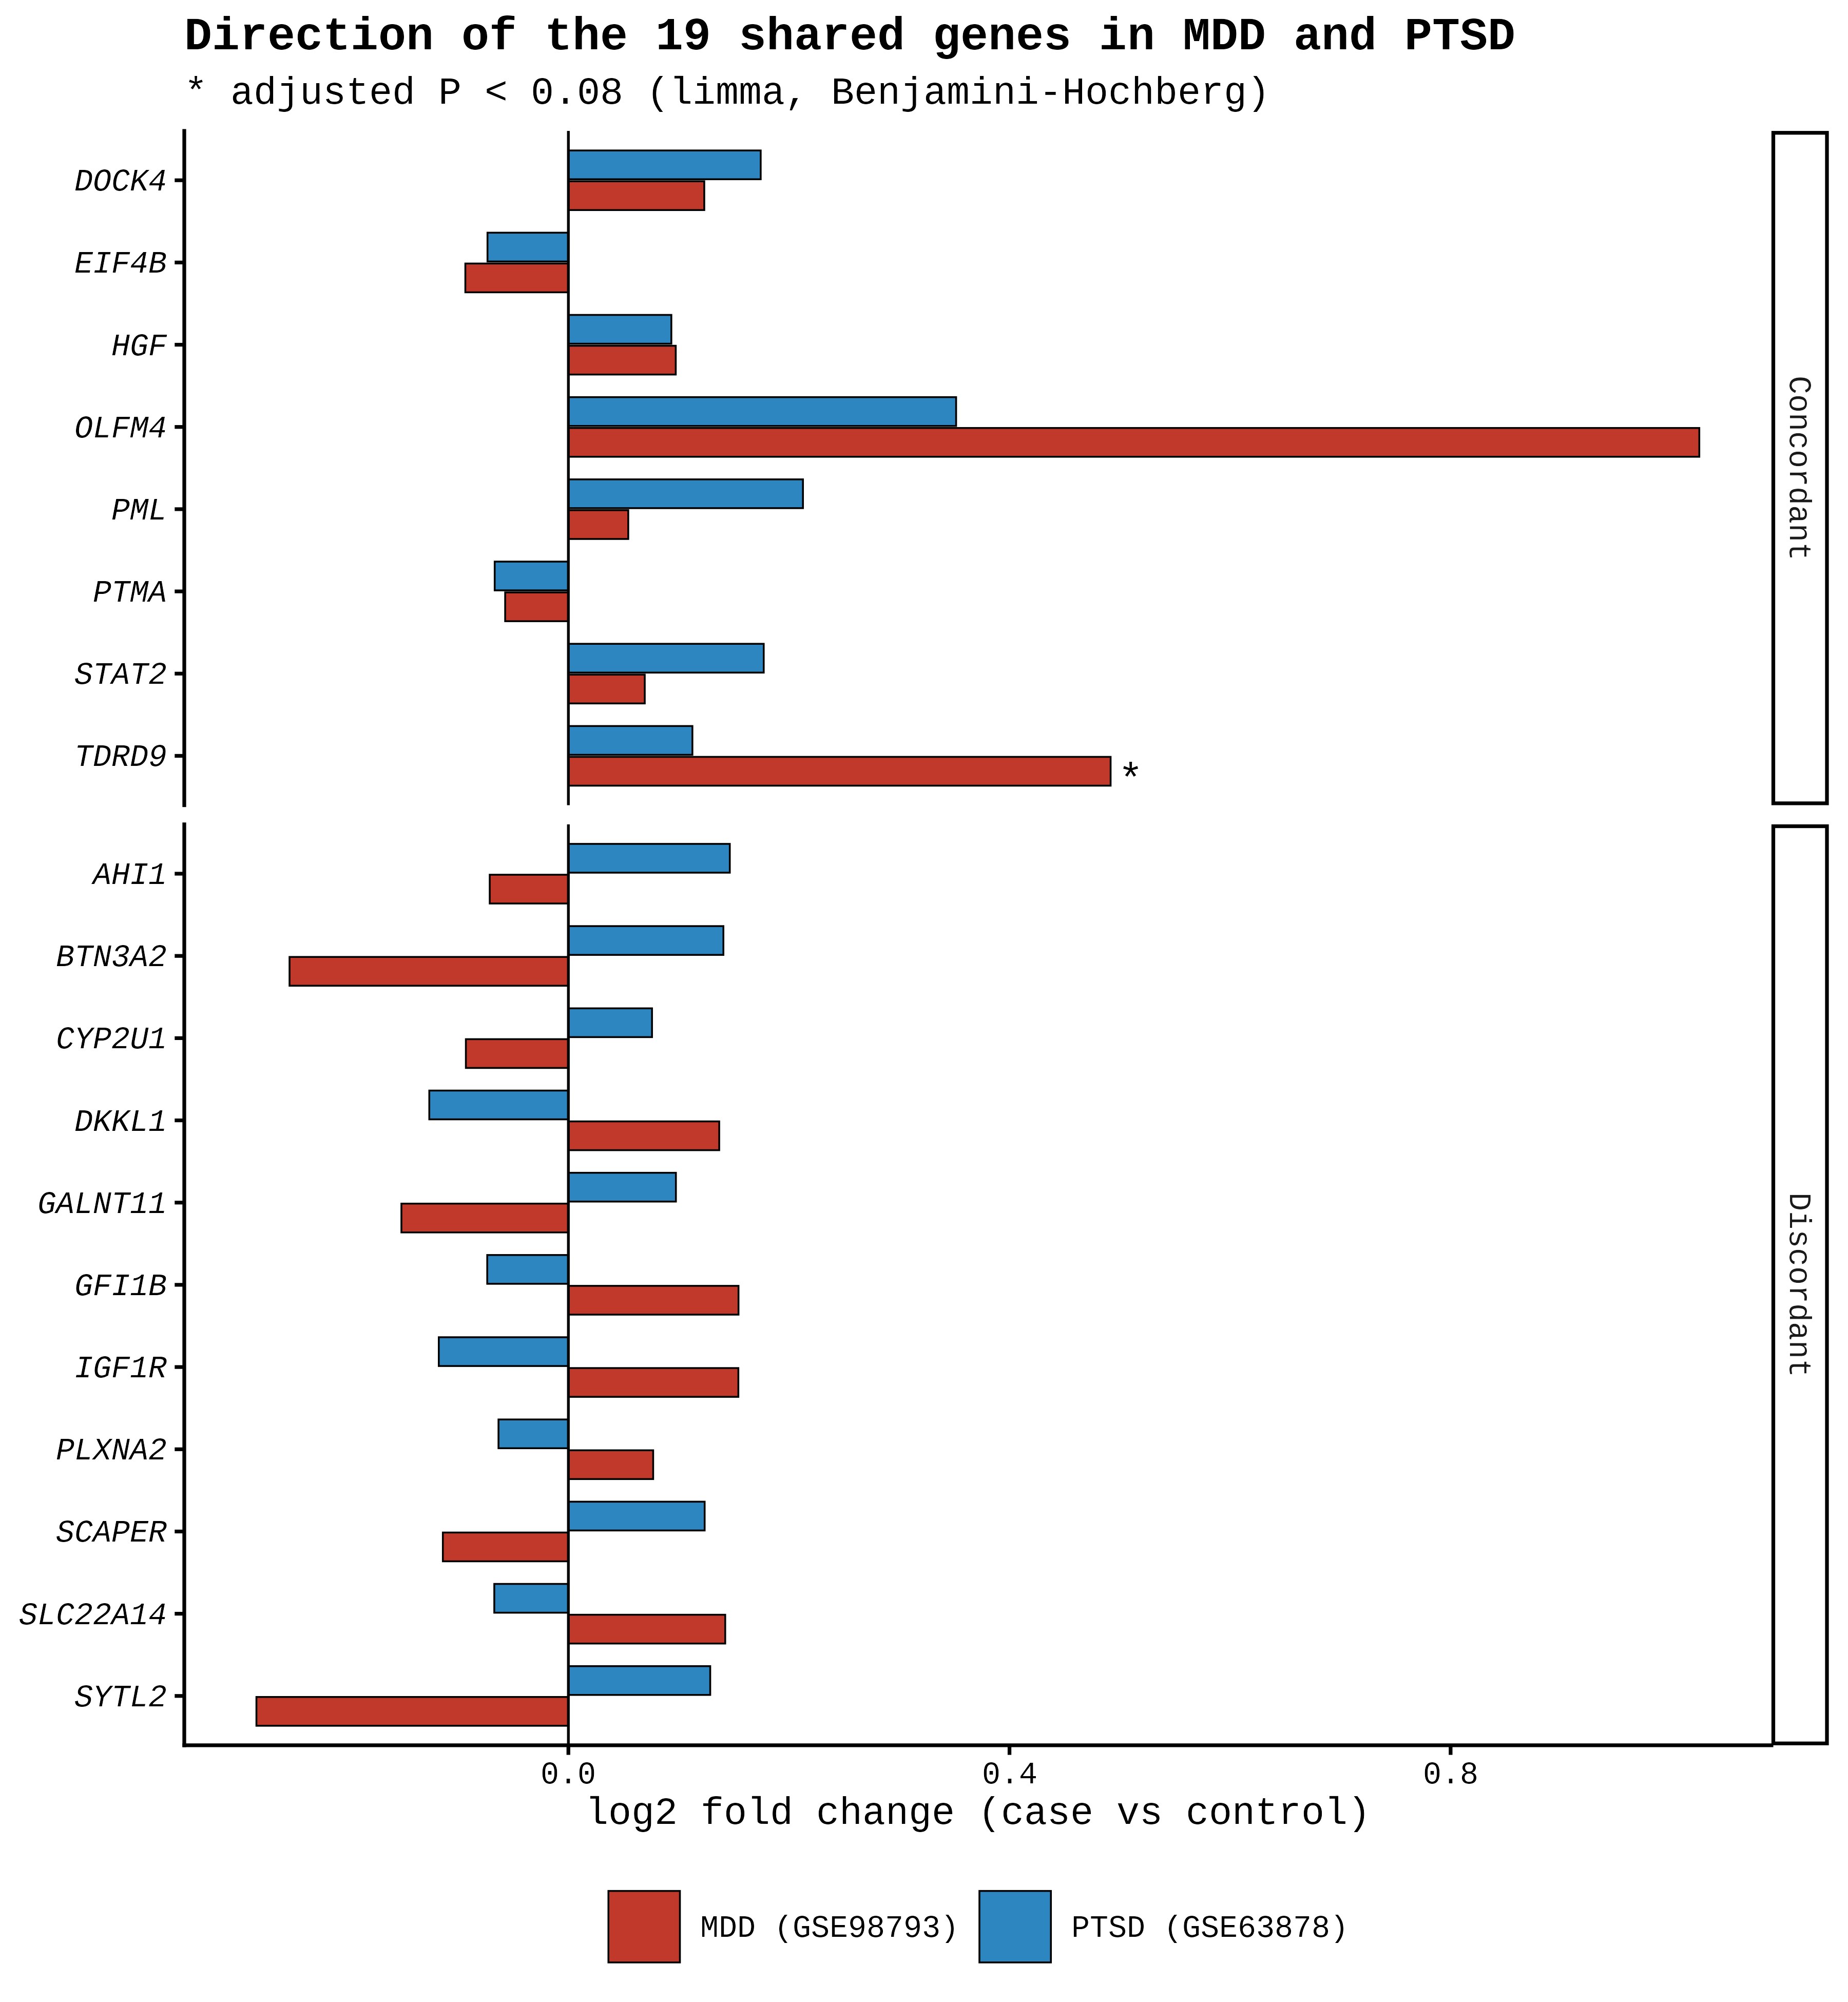

In [ ]:
R_CODE = r'''
options(stringsAsFactors = FALSE, warn = 1)
suppressPackageStartupMessages({ library(limma); library(data.table); library(ggplot2) })

ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT  <- paste0(ROOT, "SharedGenes_Reviewer10/"); dir.create(OUT, showWarnings = FALSE, recursive = TRUE)
SETS <- list(MDD  = list(gse = "GSE98793", full = paste0(ROOT, "Final_validation/GSE98793_matrix_Transpose_labeled.csv"),
                         score = paste0(ROOT, "process_datasets_0.08/score/GSE98793_matrix_Transpose_labeled_Fisher_Scores.csv")),
             PTSD = list(gse = "GSE63878", full = paste0(ROOT, "Final_validation/GSE63878_matrix_Transpose_labeled.csv"),
                         score = paste0(ROOT, "process_datasets_0.08/score/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv")))
SHARED <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R","GALNT11",
            "HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")
FDR_CUT <- 0.08; TOP_N <- 800

gene_matrix <- function(path) {
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  y <- as.integer(df$target == 1)
  X <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X)); keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  M <- as.matrix(X[, keep]); sym <- sym[keep]
  if (max(M, na.rm = TRUE) > 50) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  list(G = G, y = y)
}

rows <- list()
for (dis in names(SETS)) {
  s <- SETS[[dis]]
  g <- gene_matrix(s$full)
  grp <- factor(ifelse(g$y == 1, "case", "control"), levels = c("control", "case"))
  fit <- eBayes(lmFit(t(g$G), model.matrix(~ grp)))
  tt <- topTable(fit, coef = 2, number = Inf, sort.by = "none", adjust.method = "BH")
  fs <- read.csv(s$score); fs <- fs[order(-fs$Fisher.Score), ]; fs$Rank <- seq_len(nrow(fs))
  cat(sprintf("%s (%s): limma on %d genes (%d with adj. P < %.2f); %d genes Fisher-ranked\n",
              dis, s$gse, nrow(tt), sum(tt$adj.P.Val < FDR_CUT), FDR_CUT, nrow(fs)))
  for (gn in SHARED) {
    inT <- gn %in% rownames(tt); r <- match(gn, fs$Feature)
    lf <- if (inT) tt[gn, "logFC"] else NA
    rows[[length(rows) + 1]] <- data.frame(Gene = gn, Disorder = dis, Dataset = s$gse,
      log2FC = lf, P_value = if (inT) tt[gn, "P.Value"] else NA, adj_P = if (inT) tt[gn, "adj.P.Val"] else NA,
      Direction = ifelse(is.na(lf), NA, ifelse(lf > 0, "Up", "Down")),
      Fisher_score = if (!is.na(r)) fs$Fisher.Score[r] else NA, Fisher_rank = if (!is.na(r)) fs$Rank[r] else NA,
      Genes_ranked = nrow(fs))
  }
}
long <- do.call(rbind, rows)
write.csv(long, paste0(OUT, "S19_shared_genes_long.csv"), row.names = FALSE)

w <- merge(long[long$Disorder == "MDD", ], long[long$Disorder == "PTSD", ], by = "Gene", suffixes = c("_MDD", "_PTSD"))
w <- w[match(SHARED, w$Gene), ]
w$Concordance <- ifelse(w$Direction_MDD == w$Direction_PTSD, "Concordant", "Discordant")
tab <- data.frame(Gene = w$Gene,
  `MDD log2FC` = round(w$log2FC_MDD, 3), `MDD adj. P` = signif(w$adj_P_MDD, 3), `MDD direction` = w$Direction_MDD,
  `MDD Fisher rank` = paste0(w$Fisher_rank_MDD, "/", w$Genes_ranked_MDD),
  `PTSD log2FC` = round(w$log2FC_PTSD, 3), `PTSD adj. P` = signif(w$adj_P_PTSD, 3), `PTSD direction` = w$Direction_PTSD,
  `PTSD Fisher rank` = paste0(w$Fisher_rank_PTSD, "/", w$Genes_ranked_PTSD),
  Concordance = w$Concordance, check.names = FALSE)
tab <- tab[order(tab$Concordance, tab$Gene), ]
write.csv(tab, paste0(OUT, "Table_shared_genes_both_datasets.csv"), row.names = FALSE)

pd <- data.frame(Gene = factor(rep(w$Gene, 2), levels = rev(tab$Gene)),
                 Disorder = rep(c("MDD (GSE98793)", "PTSD (GSE63878)"), each = nrow(w)),
                 log2FC = c(w$log2FC_MDD, w$log2FC_PTSD), adjP = c(w$adj_P_MDD, w$adj_P_PTSD),
                 Concordance = rep(w$Concordance, 2))
pd$Sig <- ifelse(pd$adjP < FDR_CUT, "*", "")
p <- ggplot(pd, aes(log2FC, Gene, fill = Disorder)) +
  geom_col(position = position_dodge(0.75), width = 0.7, colour = "black", linewidth = 0.2) +
  geom_text(aes(label = Sig, hjust = ifelse(log2FC > 0, -0.3, 1.3)), position = position_dodge(0.75), size = 3.5, vjust = 0.75) +
  geom_vline(xintercept = 0, linewidth = 0.3) +
  scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  facet_grid(Concordance ~ ., scales = "free_y", space = "free_y") +
  labs(x = "log2 fold change (case vs control)", y = NULL,
       title = "Direction of the 19 shared genes in MDD and PTSD",
       subtitle = sprintf("* adjusted P < %.2f (limma, Benjamini-Hochberg)", FDR_CUT)) +
  theme_classic(base_size = 9) +
  theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"), plot.title = element_text(face = "bold"))
for (ext in c("png", "tiff")) ggsave(paste0(OUT, "FigS6_shared_genes_log2FC.", ext), p, width = 6, height = 6.5, dpi = 600, bg = "white")
ggsave(paste0(OUT, "FigS6_shared_genes_log2FC.pdf"), p, width = 6, height = 6.5)

cat("\nConcordant:", sum(w$Concordance == "Concordant"), "| Discordant:", sum(w$Concordance == "Discordant"),
    "\nadj. P <", FDR_CUT, "in MDD:", sum(w$adj_P_MDD < FDR_CUT, na.rm = TRUE), "| in PTSD:", sum(w$adj_P_PTSD < FDR_CUT, na.rm = TRUE),
    "| in both:", sum(w$adj_P_MDD < FDR_CUT & w$adj_P_PTSD < FDR_CUT, na.rm = TRUE),
    "\nIn top", TOP_N, "MDD:", sum(w$Fisher_rank_MDD <= TOP_N, na.rm = TRUE), "| PTSD:", sum(w$Fisher_rank_PTSD <= TOP_N, na.rm = TRUE), "\n")
'''
open("/content/shared_genes_r10.R", "w").write(R_CODE)

import subprocess, sys, pandas as pd
from IPython.display import display, Image
proc = subprocess.Popen(["Rscript", "/content/shared_genes_r10.R"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout: sys.stdout.write(line)
proc.wait(); print("exit code:", proc.returncode)

OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/SharedGenes_Reviewer10/"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
display(pd.read_csv(OUT + "Table_shared_genes_both_datasets.csv"))
display(Image(OUT + "FigS6_shared_genes_log2FC.png", width=600))

In [ ]:
R_CHECK = r'''
suppressPackageStartupMessages({ library(limma); library(data.table) })
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
gene_matrix <- function(path) {
  df <- fread(path, data.table = FALSE, check.names = FALSE); y <- as.integer(df$target == 1)
  X <- df[, setdiff(colnames(df), "target"), drop = FALSE]; X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X)); keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  M <- as.matrix(X[, keep]); sym <- sym[keep]; if (max(M, na.rm = TRUE) > 50) M <- log2(pmax(M, 0) + 1)
  list(M = M, sym = sym, y = y)
}
for (g in c("GSE98793", "GSE63878")) {
  d <- gene_matrix(paste0(ROOT, "Final_validation/", g, "_matrix_Transpose_labeled.csv"))
  grp <- factor(ifelse(d$y == 1, "case", "control"), levels = c("control", "case")); des <- model.matrix(~ grp)
  ## probe level (as in many GEO2R/limma pipelines)
  tp <- topTable(eBayes(lmFit(t(d$M), des)), coef = 2, number = Inf, sort.by = "none")
  deg <- colnames(fread(paste0(ROOT, "process_datasets_0.08/datasets/", g, "_matrix_Transpose_labeled.csv"), nrows = 0))
  deg <- unique(sub("\\.[0-9]+$", "", setdiff(deg, "target")))
  cat(sprintf("\n%s: %d probes; your DEG list = %d genes\n", g, nrow(tp), length(deg)))
  for (cut in c(0.05, 0.08)) {
    nom <- unique(d$sym[tp$P.Value < cut]); adj <- unique(d$sym[tp$adj.P.Val < cut])
    j <- function(a, b) round(length(intersect(a, b)) / length(union(a, b)), 3)
    cat(sprintf("  p < %.2f: nominal %d genes (Jaccard with your list %.3f) | adjusted %d genes (Jaccard %.3f)\n",
                cut, length(nom), j(nom, deg), length(adj), j(adj, deg)))
  }
}
'''
open("/content/check_deg.R", "w").write(R_CHECK)
import subprocess; print(subprocess.run(["Rscript", "/content/check_deg.R"], capture_output=True, text=True).stdout)


GSE98793: 42904 probes; your DEG list = 3744 genes
  p < 0.05: nominal 2447 genes (Jaccard with your list 0.654) | adjusted 4 genes (Jaccard 0.001)
  p < 0.08: nominal 3546 genes (Jaccard with your list 0.947) | adjusted 13 genes (Jaccard 0.003)

GSE63878: 19697 probes; your DEG list = 829 genes
  p < 0.05: nominal 445 genes (Jaccard with your list 0.537) | adjusted 0 genes (Jaccard 0.000)
  p < 0.08: nominal 787 genes (Jaccard with your list 0.947) | adjusted 0 genes (Jaccard 0.000)



#Comment 3,4,7

In [2]:
# =====================================================================================
# THRESHOLD SENSITIVITY ANALYSIS  (Reviewer #2, Concern #3)  -- Colab, plain Python
#   DEGs selected at nominal p < 0.05 or < 0.08 (GEO2R P.Value); Fisher top 500/800/1000.
#   Reports gene-level overlap, effect directions, rank correlations, pathway stability and the
#   top 10 hub genes of each setting (STRING/CytoHubba results from the original network analysis).
# =====================================================================================
import os, re, subprocess, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr, hypergeom
try:
    from adjustText import adjust_text
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "adjustText"]); from adjustText import adjust_text
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "Threshold_Sensitivity_Reviewer3/"; os.makedirs(OUT, exist_ok=True)
DS = {"MDD": "GSE98793", "PTSD": "GSE63878"}
THR = ["0.05", "0.08"]; TOPS = [500, 800, 1000]; MAIN = ("0.08", 800)
SCORE = lambda t, g: ROOT + f"process_datasets_{t}/score/{g}_matrix_Transpose_labeled_Fisher_Scores.csv"
DATA  = lambda t, g: ROOT + f"process_datasets_{t}/datasets/{g}_matrix_Transpose_labeled.csv"
LIBDIR = ROOT + "Enrichment_Reviewer12/libraries/"
LIBS = ["KEGG_2021_Human", "WikiPathways_2024_Human"]
UNIV_FILES = [ROOT + "Final_validation/GSE98793_matrix_Transpose_labeled.csv", ROOT + "Final_validation/GSE63878_matrix_Transpose_labeled.csv"]
# Top 10 hub genes (CytoHubba degree) of the STRING network for each setting, from the original network analysis
HUB = {("0.08", 500):  ["EIF4B", "EIF3B", "RPS6KB1", "RPS6", "EIF2S3", "EIF4G1", "EIF2S1", "EIF4E", "EIF4A1", "EIF4G2"],
       ("0.08", 800):  ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"],
       ("0.08", 1000): ["DOCK4", "BARD1", "IGF1R", "STAT2", "EIF4B", "PML", "GRB10", "HGF", "RPS6", "INS"],
       ("0.05", 800):  ["DOCK4", "EIF4B", "RPS6", "RPS19", "EEF2", "RPS28", "RPS6KB2", "RPS10", "RPL15", "RPS10-NUDT3"],
       ("0.05", 1000): ["DOCK4", "EIF4B", "RPS6", "RPS19", "EEF2", "RPS28", "RPS6KB2", "RPS10", "RPL15", "RPS10-NUDT3"]}
SEEDS = ["IGF1R", "STAT2", "HGF", "PML"]

# ------------------------------------------------------------------ 1. Fisher-score lists + Table 2
F = {}
for t in THR:
    for dis, g in DS.items():
        s = pd.read_csv(SCORE(t, g)).sort_values("Fisher Score", ascending=False).reset_index(drop=True)
        s["Rank"] = np.arange(1, len(s) + 1); F[(t, dis)] = s
top = lambda t, dis, n: list(F[(t, dis)].Feature.head(n))
shared = {(t, n): sorted(set(top(t, "MDD", n)) & set(top(t, "PTSD", n))) for t in THR for n in TOPS}
REF = set(shared[MAIN])
# identical input genes give an identical network: p<0.05 Top500 takes the hub genes of p<0.08 Top500 if the gene sets match
if shared[("0.05", 500)] == shared[("0.08", 500)]:
    HUB[("0.05", 500)] = HUB[("0.08", 500)]

rows = []
for t in THR:
    for n in TOPS:
        s = set(shared[(t, n)]); hub = HUB.get((t, n))
        rows.append({"Nominal p cut-off": t, "Fisher top-N": n,
                     "DEGs MDD": len(F[(t, "MDD")]), "DEGs PTSD": len(F[(t, "PTSD")]),
                     "Genes used MDD": min(n, len(F[(t, "MDD")])), "Genes used PTSD": min(n, len(F[(t, "PTSD")])),
                     "Mean Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).mean():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).mean():.4f}",
                     "Median Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).median():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).median():.4f}",
                     "Shared genes": len(s), "Overlap with main 19": len(s & REF),
                     "Jaccard vs main": round(len(s & REF) / len(s | REF), 2) if s | REF else np.nan,
                     "Seed genes retained": ", ".join(g for g in SEEDS if g in s) or "none",
                     "Shared genes list": ", ".join(sorted(s)),
                     "Top 10 hub genes (degree)": ", ".join(hub) if hub else "not available",
                     "Hub overlap with primary": (len(set(hub) & set(HUB[MAIN])) if hub else "")})
grid = pd.DataFrame(rows); grid.to_csv(OUT + "Table2_revised_threshold_grid.csv", index=False, encoding="utf-8-sig")
grid[["Nominal p cut-off", "Fisher top-N", "DEGs MDD", "DEGs PTSD", "Genes used MDD", "Genes used PTSD", "Shared genes",
      "Overlap with main 19", "Seed genes retained", "Top 10 hub genes (degree)", "Hub overlap with primary"]].to_csv(
      OUT + "Table2_publication.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 2. Rank correlations
rc = []
for dis in DS:
    a, b = F[("0.05", dis)], F[("0.08", dis)]
    m = a.merge(b, on="Feature", suffixes=("_05", "_08"))
    rho, _ = spearmanr(m["Fisher Score_05"], m["Fisher Score_08"])
    for n in TOPS:
        A, B = set(top("0.05", dis, n)), set(top("0.08", dis, n))
        rc.append(dict(Comparison=f"{dis}: 0.05 vs 0.08", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                       Top_N=n, Top_N_overlap=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2)))
for t in THR:
    m = F[(t, "MDD")].merge(F[(t, "PTSD")], on="Feature", suffixes=("_MDD", "_PTSD"))
    rho, p = spearmanr(m["Fisher Score_MDD"], m["Fisher Score_PTSD"]) if len(m) > 2 else (np.nan, np.nan)
    rc.append(dict(Comparison=f"MDD vs PTSD at {t}", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                   Spearman_p=p, Top_N=np.nan, Top_N_overlap=np.nan, Jaccard=np.nan))
rc = pd.DataFrame(rc); rc.to_csv(OUT + "S_rank_correlations.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 3. Effect directions (log2 fold change)
def log2fc(path, genes):
    cols = pd.read_csv(path, nrows=0).columns
    use = [c for c in cols if re.sub(r"\.\d+$", "", c) in genes] + ["target"]
    df = pd.read_csv(path, usecols=use); y = df.pop("target").values == 1
    df.columns = [re.sub(r"\.\d+$", "", c) for c in df.columns]
    df = df.T.groupby(level=0).mean().T
    return (df[y].mean() - df[~y].mean())
union = sorted(set().union(*[set(v) for v in shared.values()]))
fc = {dis: log2fc(DATA("0.08", g), set(union)) for dis, g in DS.items()}
eff = pd.DataFrame({"Gene": union})
for dis in DS:
    eff[f"log2FC {dis}"] = eff.Gene.map(fc[dis]).round(3)
    eff[f"Direction {dis}"] = np.where(eff[f"log2FC {dis}"] > 0, "Up", "Down")
    for t in THR:
        r = F[(t, dis)].set_index("Feature")["Rank"]
        eff[f"Fisher rank {dis} {t}"] = eff.Gene.map(r).astype("Int64")
eff["Concordant direction"] = np.where(eff["Direction MDD"] == eff["Direction PTSD"], "yes", "no")
for t in THR:
    for n in TOPS:
        eff[f"Shared {t} Top{n}"] = eff.Gene.isin(shared[(t, n)]).map({True: "x", False: ""})
eff["Main 19"] = eff.Gene.isin(REF).map({True: "x", False: ""})
eff["Seed gene"] = eff.Gene.isin(SEEDS).map({True: "x", False: ""})
eff.to_csv(OUT + "S_gene_level_overlap_directions.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 4. Pathway stability (KEGG, WikiPathways)
def symbols(p):
    return {g for g in {re.sub(r"\.\d+$", "", c).strip() for c in pd.read_csv(p, nrows=0).columns if c != "target"} if g and "///" not in g}
U = set.intersection(*[symbols(p) for p in UNIV_FILES]); N = len(U)
def load_lib(name):
    lib = {}
    for line in open(LIBDIR + name + ".gmt"):
        parts = line.rstrip("\n").split("\t")
        if len(parts) > 2: lib[parts[0]] = {x.split(",")[0].strip() for x in parts[2:] if x.strip()}
    return lib
def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = p[o] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]; out = np.empty(n); out[o] = np.minimum(q, 1); return out
def enrich(genes, lib):
    G = set(genes) & U; n = len(G); rows = []
    for term, mem in lib.items():
        T = mem & U; K = len(T)
        if K < 5 or K > 2000: continue
        k = len(G & T)
        if k: rows.append((term, k, K, hypergeom.sf(k - 1, N, K, n), ";".join(sorted(G & T))))
    d = pd.DataFrame(rows, columns=["Term", "k", "K", "P", "Genes"])
    if len(d): d["FDR"] = bh(d.P)
    return d
SETS = {"Shared genes 0.08 Top800 (19)": shared[("0.08", 800)], "Shared genes 0.05 Top800": shared[("0.05", 800)],
        "Hub genes 0.08 Top800": HUB[("0.08", 800)], "Hub genes 0.05 Top800": HUB[("0.05", 800)]}
pw, sigsets = [], {}
for lname in LIBS:
    lib = load_lib(lname)
    for sname, genes in SETS.items():
        d = enrich(genes, lib)
        sig = set(d.Term[d.FDR < 0.05]) if len(d) else set(); sigsets[(lname, sname)] = sig
        if not len(d): continue
        for _, r in d.sort_values("FDR").head(10).iterrows():
            pw.append(dict(Library=lname, Gene_set=sname, Term=r.Term, Overlap=f"{r.k}/{r.K}", FDR=r.FDR, Genes=r.Genes))
pw = pd.DataFrame(pw); pw.to_csv(OUT + "S_pathway_top_terms_by_threshold.csv", index=False, encoding="utf-8-sig")
stab = []
for lname in LIBS:
    for a, b in [("Shared genes 0.08 Top800 (19)", "Shared genes 0.05 Top800"), ("Hub genes 0.08 Top800", "Hub genes 0.05 Top800")]:
        A, B = sigsets[(lname, a)], sigsets[(lname, b)]
        stab.append(dict(Library=lname, Comparison=f"{a} vs {b}", Significant_A=len(A), Significant_B=len(B),
                         Shared_significant=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2) if A | B else np.nan,
                         Example_shared_terms="; ".join(sorted(A & B)[:5])))
stab = pd.DataFrame(stab); stab.to_csv(OUT + "S_pathway_stability.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT + "Threshold_sensitivity_all_tables.xlsx") as xw:
    grid.to_excel(xw, sheet_name="Table2_revised", index=False); eff.to_excel(xw, sheet_name="Gene_overlap_direction", index=False)
    rc.to_excel(xw, sheet_name="Rank_correlations", index=False); stab.to_excel(xw, sheet_name="Pathway_stability", index=False)
    pw.to_excel(xw, sheet_name="Pathway_top_terms", index=False)

# ------------------------------------------------------------------ 5. Figures (no overlapping labels)
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
def save(fig, nm):
    for ext in ("png", "tiff"): fig.savefig(OUT + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + nm + ".pdf", bbox_inches="tight"); plt.close(fig)

# S3 Fig A: presence across the six settings + effect direction
settings = [(t, n) for t in THR for n in TOPS]
eff["main"] = eff["Main 19"] == "x"
order = eff.sort_values(["main", "Gene"], ascending=[False, True]).Gene.tolist()
M = np.array([[1 if g in shared[s_] else 0 for s_ in settings] for g in order])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.2, 0.24 * len(order) + 2.0), gridspec_kw={"width_ratios": [3, 1.4], "wspace": 0.08}, sharey=True)
a1.imshow(M, aspect="auto", cmap="Greys", vmin=0, vmax=1.4)
for x in np.arange(-0.5, len(settings), 1): a1.axvline(x, color="white", lw=1.2)
for y in np.arange(-0.5, len(order), 1): a1.axhline(y, color="white", lw=0.6)
a1.axvline(2.5, color="black", lw=1)
a1.set_xticks(range(len(settings))); a1.set_xticklabels([f"Top {n}" for _, n in settings], fontsize=7)
for i_, t in enumerate(THR):
    a1.text(1 + 3 * i_, -1.6, f"nominal p < {t}", ha="center", va="bottom", fontsize=8, fontweight="bold")
a1.set_ylim(len(order) - 0.5, -2.2)
a1.set_yticks(range(len(order))); a1.set_yticklabels([g + (" *" if g in SEEDS else "") for g in order], fontstyle="italic")
a1.axhline(int(eff["main"].sum()) - 0.5, color="#C0392B", lw=1.2, ls="--")
a1.set_title("A  Shared gene present (grey)", loc="left", fontweight="bold", pad=22)
e = eff.set_index("Gene").loc[order]; yy = np.arange(len(order))
a2.barh(yy - 0.2, e["log2FC MDD"], 0.4, color="#C0392B", label="MDD"); a2.barh(yy + 0.2, e["log2FC PTSD"], 0.4, color="#2E86C1", label="PTSD")
a2.axvline(0, color="black", lw=0.5); a2.set_xlabel("log2 fold change"); a2.legend(fontsize=7, frameon=False, loc="lower right")
a2.set_title("B  Effect direction", loc="left", fontweight="bold", pad=22)
fig.text(0.01, 0.005, "* seed genes of the PPI network; genes above the dashed line form the primary set (nominal p < 0.08, Top 800).", fontsize=7)
save(fig, "FigS3A_threshold_gene_stability")

# S3 Fig B: Fisher-rank agreement between thresholds, labels repelled
fig, axs = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, dis in zip(axs, DS):
    m = F[("0.05", dis)].merge(F[("0.08", dis)], on="Feature", suffixes=("_05", "_08"))
    rho = rc[(rc.Comparison == f"{dis}: 0.05 vs 0.08")].Spearman_rho.iloc[0]
    ax.scatter(m["Rank_08"], m["Rank_05"], s=3, alpha=0.35, color="#7F8C8D", rasterized=True)
    hl = m[m.Feature.isin(REF)]
    ax.scatter(hl["Rank_08"], hl["Rank_05"], s=16, color="#C0392B", zorder=3)
    lim = max(hl["Rank_08"].max(), hl["Rank_05"].max()) * 1.15 if dis == "MDD" else None
    if lim: ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    texts = [ax.text(r["Rank_08"], r["Rank_05"], r.Feature, fontsize=6.5, fontstyle="italic") for _, r in hl.iterrows()]
    adjust_text(texts, ax=ax, expand=(1.3, 1.6), arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))
    ax.set_xlabel("Fisher rank at nominal p < 0.08"); ax.set_ylabel("Fisher rank at nominal p < 0.05")
    sub = " (ranks 1\u2013%d shown)" % int(lim) if lim else ""
    ax.set_title(f"{'A' if dis == 'MDD' else 'B'}  {dis} ({DS[dis]}); Spearman \u03c1 = {rho:.3f}{sub}", loc="left", fontweight="bold", fontsize=8)
fig.tight_layout(); save(fig, "FigS3B_threshold_rank_agreement")

pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 80)
print("REVISED TABLE 2\n", grid.drop(columns=["Shared genes list"]).to_string(index=False))
print("\nRANK CORRELATIONS\n", rc.to_string(index=False))
print("\nPATHWAY STABILITY\n", stab.to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REVISED TABLE 2
 Nominal p cut-off  Fisher top-N  DEGs MDD  DEGs PTSD  Genes used MDD  Genes used PTSD Mean Fisher MDD / PTSD Median Fisher MDD / PTSD  Shared genes  Overlap with main 19  Jaccard vs main    Seed genes retained                                                  Top 10 hub genes (degree)  Hub overlap with primary
             0.05           500      3115        496             500              496        0.0545 / 0.0620          0.0500 / 0.0553             6                     6             0.32                    PML EIF4B, EIF3B, RPS6KB1, RPS6, EIF2S3, EIF4G1, EIF2S1, EIF4E, EIF4A1, EIF4G2                         0
             0.05           800      3115        496             800              496        0.0485 / 0.0620          0.0444 / 0.0553            11                    11             0.58                    PML DOCK4, EIF4B, RPS6, RP

In [ ]:
# =====================================================================================
# THRESHOLD SENSITIVITY ANALYSIS  (Reviewer #2, Concern #3)  -- Colab, plain Python
#   DEGs were selected at nominal p < 0.05 or < 0.08 (GEO2R P.Value); Fisher top 500/800/1000.
#   Reports gene-level overlap, effect directions, rank correlations and pathway stability.
# =====================================================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr, hypergeom
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "Threshold_Sensitivity_Reviewer3/"; os.makedirs(OUT, exist_ok=True)
DS = {"MDD": "GSE98793", "PTSD": "GSE63878"}
THR = ["0.05", "0.08"]; TOPS = [500, 800, 1000]; MAIN = ("0.08", 800)
SCORE = lambda t, g: ROOT + f"process_datasets_{t}/score/{g}_matrix_Transpose_labeled_Fisher_Scores.csv"
DATA  = lambda t, g: ROOT + f"process_datasets_{t}/datasets/{g}_matrix_Transpose_labeled.csv"
LIBDIR = ROOT + "Enrichment_Reviewer12/libraries/"
LIBS = ["KEGG_2021_Human", "WikiPathways_2024_Human"]
UNIV_FILES = [ROOT + "Final_validation/GSE98793_matrix_Transpose_labeled.csv", ROOT + "Final_validation/GSE63878_matrix_Transpose_labeled.csv"]
# Hub genes reported in Table 2 for the Top-800 analyses (from the STRING/CytoHubba step)
HUB = {("0.08", 800): ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"],
       ("0.05", 800): ["DOCK4", "EIF4B", "RPS6", "RPS19", "EEF2", "RPS28", "RPS6KB2", "RPS10", "RPL15", "RPS10-NUDT3"]}
SEEDS = ["IGF1R", "STAT2", "HGF", "PML"]

# ------------------------------------------------------------------ 1. Fisher-score lists
F = {}
for t in THR:
    for dis, g in DS.items():
        s = pd.read_csv(SCORE(t, g)).sort_values("Fisher Score", ascending=False).reset_index(drop=True)
        s["Rank"] = np.arange(1, len(s) + 1); F[(t, dis)] = s
top = lambda t, dis, n: list(F[(t, dis)].Feature.head(n))
shared = {(t, n): sorted(set(top(t, "MDD", n)) & set(top(t, "PTSD", n))) for t in THR for n in TOPS}
REF = set(shared[MAIN])

rows = []
for t in THR:
    for n in TOPS:
        s = set(shared[(t, n)]); hub = HUB.get((t, n))
        rows.append({"Nominal p cut-off": t, "Fisher top-N": n,
                     "DEGs MDD": len(F[(t, "MDD")]), "DEGs PTSD": len(F[(t, "PTSD")]),
                     "Genes used MDD": min(n, len(F[(t, "MDD")])), "Genes used PTSD": min(n, len(F[(t, "PTSD")])),
                     "Mean Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).mean():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).mean():.4f}",
                     "Median Fisher MDD / PTSD": f"{F[(t,'MDD')]['Fisher Score'].head(n).median():.4f} / {F[(t,'PTSD')]['Fisher Score'].head(n).median():.4f}",
                     "Shared genes": len(s), "Overlap with main 19": len(s & REF),
                     "Jaccard vs main": round(len(s & REF) / len(s | REF), 2) if s | REF else np.nan,
                     "Seed genes retained": ", ".join(g for g in SEEDS if g in s) or "none",
                     "Shared genes list": ", ".join(sorted(s)),
                     "Hub genes (Table 2)": ", ".join(hub) if hub else "not computed",
                     "Hub overlap with main": (len(set(hub) & set(HUB[MAIN])) if hub else np.nan)})
grid = pd.DataFrame(rows); grid.to_csv(OUT + "Table2_revised_threshold_grid.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 2. Rank correlations
rc = []
for dis in DS:
    a, b = F[("0.05", dis)], F[("0.08", dis)]
    m = a.merge(b, on="Feature", suffixes=("_05", "_08"))
    rho, _ = spearmanr(m["Fisher Score_05"], m["Fisher Score_08"])
    for n in TOPS:
        A, B = set(top("0.05", dis, n)), set(top("0.08", dis, n))
        rc.append(dict(Comparison=f"{dis}: 0.05 vs 0.08", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                       Top_N=n, Top_N_overlap=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2)))
for t in THR:
    m = F[(t, "MDD")].merge(F[(t, "PTSD")], on="Feature", suffixes=("_MDD", "_PTSD"))
    rho, p = spearmanr(m["Fisher Score_MDD"], m["Fisher Score_PTSD"]) if len(m) > 2 else (np.nan, np.nan)
    rc.append(dict(Comparison=f"MDD vs PTSD at {t}", Genes_compared=len(m), Spearman_rho=round(rho, 3),
                   Spearman_p=p, Top_N=np.nan, Top_N_overlap=np.nan, Jaccard=np.nan))
rc = pd.DataFrame(rc); rc.to_csv(OUT + "S_rank_correlations.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 3. Effect directions (log2 fold change)
def log2fc(path, genes):
    cols = pd.read_csv(path, nrows=0).columns
    use = [c for c in cols if re.sub(r"\.\d+$", "", c) in genes] + ["target"]
    df = pd.read_csv(path, usecols=use); y = df.pop("target").values == 1
    df.columns = [re.sub(r"\.\d+$", "", c) for c in df.columns]
    df = df.T.groupby(level=0).mean().T
    return (df[y].mean() - df[~y].mean())
union = sorted(set().union(*[set(v) for v in shared.values()]))
fc = {dis: log2fc(DATA("0.08", g), set(union)) for dis, g in DS.items()}
eff = pd.DataFrame({"Gene": union})
for dis in DS:
    eff[f"log2FC {dis}"] = eff.Gene.map(fc[dis]).round(3)
    eff[f"Direction {dis}"] = np.where(eff[f"log2FC {dis}"] > 0, "Up", "Down")
    for t in THR:
        r = F[(t, dis)].set_index("Feature")["Rank"]
        eff[f"Fisher rank {dis} {t}"] = eff.Gene.map(r).astype("Int64")
eff["Concordant direction"] = np.where(eff["Direction MDD"] == eff["Direction PTSD"], "yes", "no")
for t in THR:
    for n in TOPS:
        eff[f"Shared {t} Top{n}"] = eff.Gene.isin(shared[(t, n)]).map({True: "x", False: ""})
eff["Main 19"] = eff.Gene.isin(REF).map({True: "x", False: ""})
eff["Seed gene"] = eff.Gene.isin(SEEDS).map({True: "x", False: ""})
eff.to_csv(OUT + "S_gene_level_overlap_directions.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------ 4. Pathway stability (KEGG, WikiPathways)
def symbols(p):
    return {g for g in {re.sub(r"\.\d+$", "", c).strip() for c in pd.read_csv(p, nrows=0).columns if c != "target"} if g and "///" not in g}
U = set.intersection(*[symbols(p) for p in UNIV_FILES]); N = len(U)
def load_lib(name):
    lib = {}
    for line in open(LIBDIR + name + ".gmt"):
        parts = line.rstrip("\n").split("\t")
        if len(parts) > 2: lib[parts[0]] = {x.split(",")[0].strip() for x in parts[2:] if x.strip()}
    return lib
def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = p[o] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]; out = np.empty(n); out[o] = np.minimum(q, 1); return out
def enrich(genes, lib):
    G = set(genes) & U; n = len(G); rows = []
    for term, mem in lib.items():
        T = mem & U; K = len(T)
        if K < 5 or K > 2000: continue
        k = len(G & T)
        if k: rows.append((term, k, K, hypergeom.sf(k - 1, N, K, n), ";".join(sorted(G & T))))
    d = pd.DataFrame(rows, columns=["Term", "k", "K", "P", "Genes"])
    if len(d): d["FDR"] = bh(d.P)
    return d
SETS = {"Shared genes 0.08 Top800 (19)": shared[("0.08", 800)], "Shared genes 0.05 Top800": shared[("0.05", 800)],
        "Hub genes 0.08 Top800": HUB[("0.08", 800)], "Hub genes 0.05 Top800": HUB[("0.05", 800)]}
pw, sigsets = [], {}
for lname in LIBS:
    lib = load_lib(lname)
    for sname, genes in SETS.items():
        d = enrich(genes, lib)
        sig = set(d.Term[d.FDR < 0.05]) if len(d) else set(); sigsets[(lname, sname)] = sig
        if not len(d): continue
        for _, r in d.sort_values("FDR").head(10).iterrows():
            pw.append(dict(Library=lname, Gene_set=sname, Term=r.Term, Overlap=f"{r.k}/{r.K}", FDR=r.FDR, Genes=r.Genes))
pw = pd.DataFrame(pw); pw.to_csv(OUT + "S_pathway_top_terms_by_threshold.csv", index=False, encoding="utf-8-sig")
stab = []
for lname in LIBS:
    for a, b in [("Shared genes 0.08 Top800 (19)", "Shared genes 0.05 Top800"), ("Hub genes 0.08 Top800", "Hub genes 0.05 Top800")]:
        A, B = sigsets[(lname, a)], sigsets[(lname, b)]
        stab.append(dict(Library=lname, Comparison=f"{a} vs {b}", Significant_A=len(A), Significant_B=len(B),
                         Shared_significant=len(A & B), Jaccard=round(len(A & B) / len(A | B), 2) if A | B else np.nan,
                         Example_shared_terms="; ".join(sorted(A & B)[:5])))
stab = pd.DataFrame(stab); stab.to_csv(OUT + "S_pathway_stability.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT + "Threshold_sensitivity_all_tables.xlsx") as xw:
    grid.to_excel(xw, sheet_name="Table2_revised", index=False); eff.to_excel(xw, sheet_name="Gene_overlap_direction", index=False)
    rc.to_excel(xw, sheet_name="Rank_correlations", index=False); stab.to_excel(xw, sheet_name="Pathway_stability", index=False)
    pw.to_excel(xw, sheet_name="Pathway_top_terms", index=False)

# ------------------------------------------------------------------ 5. Figures
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
def save(fig, nm):
    for ext in ("png", "tiff"): fig.savefig(OUT + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + nm + ".pdf", bbox_inches="tight"); plt.close(fig)

settings = [(t, n) for t in THR for n in TOPS]
order = eff.sort_values(["Main 19", "Gene"], ascending=[False, True]).Gene.tolist()
M = np.array([[1 if g in shared[s] else 0 for s in settings] for g in order])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7, 0.22 * len(order) + 1.6), gridspec_kw={"width_ratios": [3, 1.3]}, sharey=True)
a1.imshow(M, aspect="auto", cmap="Greys", vmin=0, vmax=1.4)
a1.set_xticks(range(len(settings))); a1.set_xticklabels([f"nominal p<{t}\nTop{n}" for t, n in settings])
a1.set_yticks(range(len(order))); a1.set_yticklabels([g + (" *" if g in SEEDS else "") for g in order], fontstyle="italic")
a1.set_title("Shared gene present (black)", fontweight="bold")
e = eff.set_index("Gene").loc[order]; yy = np.arange(len(order))
a2.barh(yy - 0.2, e["log2FC MDD"], 0.4, color="#C0392B", label="MDD"); a2.barh(yy + 0.2, e["log2FC PTSD"], 0.4, color="#2E86C1", label="PTSD")
a2.axvline(0, color="black", lw=0.5); a2.set_xlabel("log2 fold change"); a2.legend(fontsize=7, frameon=False, loc="lower right")
a2.set_title("Effect direction", fontweight="bold")
fig.suptitle("Stability of shared genes across thresholds (* seed genes of the PPI network)", fontweight="bold")
fig.tight_layout(); save(fig, "FigS_threshold_gene_stability")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, dis in zip(axs, DS):
    m = F[("0.05", dis)].merge(F[("0.08", dis)], on="Feature", suffixes=("_05", "_08"))
    ax.scatter(m["Rank_08"], m["Rank_05"], s=4, alpha=0.5, color="#555555")
    hl = m[m.Feature.isin(REF)]; ax.scatter(hl["Rank_08"], hl["Rank_05"], s=18, color="#C0392B")
    for _, r in hl.iterrows(): ax.annotate(r.Feature, (r["Rank_08"], r["Rank_05"]), fontsize=6, fontstyle="italic")
    rho = rc[(rc.Comparison == f"{dis}: 0.05 vs 0.08")].Spearman_rho.iloc[0]
    ax.set_xlabel("Fisher rank at nominal p < 0.08"); ax.set_ylabel("Fisher rank at nominal p < 0.05")
    ax.set_title(f"{dis} ({DS[dis]}); Spearman \u03c1 = {rho}", fontweight="bold")
fig.tight_layout(); save(fig, "FigS_threshold_rank_agreement")

pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 80)
print("REVISED TABLE 2\n", grid.drop(columns=["Shared genes list"]).to_string(index=False))
print("\nRANK CORRELATIONS\n", rc.to_string(index=False))
print("\nPATHWAY STABILITY\n", stab.to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REVISED TABLE 2
 Nominal p cut-off  Fisher top-N  DEGs MDD  DEGs PTSD  Genes used MDD  Genes used PTSD Mean Fisher MDD / PTSD Median Fisher MDD / PTSD  Shared genes  Overlap with main 19  Jaccard vs main    Seed genes retained                                                        Hub genes (Table 2)  Hub overlap with main
             0.05           500      3115        496             500              496        0.0545 / 0.0620          0.0500 / 0.0553             6                     6             0.32                    PML                                                               not computed                    NaN
             0.05           800      3115        496             800              496        0.0485 / 0.0620          0.0444 / 0.0553            11                    11             0.58                    PML DOCK4, EIF4B, RPS6, RPS19, E

In [ ]:
# =====================================================================================
# OBJECTIVE ASSESSMENT OF THE FISHER-SCORE CUT-OFF  (Reviewer #2, Concern #4) -- Colab, Python
#   DEGs selected at nominal p < 0.08 (GEO2R P.Value)
#   1. Objective cut-off: knee (Kneedle) of the ranked Fisher-score curve (no downstream information)
#   2. Bootstrap stability: 200 stratified bootstrap samples, Nogueira stability index across cut-offs
#   3. Gene-level stability: bootstrap selection frequency of each gene and of each shared gene
#   4. Overlap versus chance: hypergeometric test and label-permutation test for each cut-off
# =====================================================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import hypergeom
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "Cutoff_Stability_Reviewer4/"; os.makedirs(OUT, exist_ok=True)
DS = {"MDD": "GSE98793", "PTSD": "GSE63878"}
THR = "0.08"                                   # primary analysis (nominal p < 0.08)
DATA = lambda g: ROOT + f"process_datasets_{THR}/datasets/{g}_matrix_Transpose_labeled.csv"
K_MAIN = 800
K_GRID = [25, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 3000]
N_BOOT, N_PERM, SEED = 200, 200, 42
PRIMARY_19 = ["TDRD9", "OLFM4", "SYTL2", "PML", "BTN3A2", "PLXNA2", "EIF4B", "CYP2U1", "IGF1R", "GALNT11",
              "HGF", "DKKL1", "GFI1B", "PTMA", "AHI1", "SCAPER", "SLC22A14", "DOCK4", "STAT2"]

# ------------------------------------------------------------------ data + Fisher score (Eq. 1)
def load(path):
    df = pd.read_csv(path); y = (df.pop("target").values == 1).astype(int)
    X = df.apply(pd.to_numeric, errors="coerce"); X = X.loc[:, X.notna().any()]
    X = X.fillna(X.mean()); X = X.loc[:, X.var() > 0]
    return X.values.astype(float), y, np.array(X.columns)
def fisher(X, y):
    mu = X.mean(0); num = np.zeros(X.shape[1]); den = np.zeros(X.shape[1])
    for c in (0, 1):
        Xc = X[y == c]; n = len(Xc); num += n * (Xc.mean(0) - mu) ** 2; den += n * Xc.var(0)
    return num / (den + 1e-10)
def ranks(fs): return np.argsort(np.argsort(-fs, kind="mergesort"), kind="mergesort")   # 0 = best
def boot(y, rng): return np.concatenate([rng.choice(np.where(y == c)[0], (y == c).sum(), replace=True) for c in (0, 1)])
def kneedle(fs):
    s = np.sort(fs)[::-1]; x = np.arange(len(s)) / (len(s) - 1); yn = (s - s.min()) / (s.max() - s.min() + 1e-12)
    return int(np.argmax((1 - x) - yn)) + 1
def nogueira(Z, k):
    B, d = Z.shape
    if k >= d: return np.nan
    p = Z.mean(0); return 1 - (B / (B - 1) * p * (1 - p)).mean() / ((k / d) * (1 - k / d))

D = {dis: dict(zip(("X", "y", "genes"), load(DATA(g)))) for dis, g in DS.items()}
for dis in DS:
    D[dis]["fs"] = fisher(D[dis]["X"], D[dis]["y"]); D[dis]["rank"] = ranks(D[dis]["fs"])
    print(f"{dis}: {D[dis]['X'].shape[0]} samples, {D[dis]['X'].shape[1]} genes")
U = sorted(set(D["MDD"]["genes"]) & set(D["PTSD"]["genes"]))          # genes that are DEGs in both datasets
top = lambda dis, r, k: set(D[dis]["genes"][r < k])
shared_obs = sorted(top("MDD", D["MDD"]["rank"], K_MAIN) & top("PTSD", D["PTSD"]["rank"], K_MAIN))
print(f"Genes that are DEGs in both datasets: {len(U)}; shared at Top-{K_MAIN}: {len(shared_obs)}")

# ------------------------------------------------------------------ 1. knee points
knee = {dis: kneedle(D[dis]["fs"]) for dis in DS}

# ------------------------------------------------------------------ 2-3. bootstrap stability and selection frequencies
rng = np.random.default_rng(SEED)
BR = {dis: np.zeros((N_BOOT, len(D[dis]["genes"])), dtype=np.int32) for dis in DS}
shared_boot = []
for b in range(N_BOOT):
    sets = {}
    for dis in DS:
        ii = boot(D[dis]["y"], rng); BR[dis][b] = ranks(fisher(D[dis]["X"][ii], D[dis]["y"][ii]))
        sets[dis] = top(dis, BR[dis][b], K_MAIN)
    shared_boot.append(sets["MDD"] & sets["PTSD"])
stab_rows = []
for dis in DS:
    p = len(D[dis]["genes"])
    for k in sorted(set([k for k in K_GRID if k < p] + [knee[dis], min(K_MAIN, p - 1)])):
        stab_rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Genes=p, K=k, Nogueira_stability=round(nogueira((BR[dis] < k).astype(np.int8), k), 3),
                              Note="knee" if k == knee[dis] else ("primary" if k == K_MAIN else "")))
stab = pd.DataFrame(stab_rows)

freq = {dis: pd.Series((BR[dis] < K_MAIN).mean(0), index=D[dis]["genes"]) for dis in DS}
sh_freq = pd.Series({g: np.mean([g in s for s in shared_boot]) for g in shared_obs})
gene_tab = pd.DataFrame({"Gene": shared_obs,
                         "In primary 19": ["yes" if g in PRIMARY_19 else "no" for g in shared_obs],
                         "Selected in MDD Top-800 (% bootstraps)": [round(100 * freq["MDD"][g], 1) for g in shared_obs],
                         "Selected in PTSD Top-800 (% bootstraps)": [round(100 * freq["PTSD"][g], 1) for g in shared_obs],
                         "Shared in both (% bootstraps)": [round(100 * sh_freq[g], 1) for g in shared_obs]}).sort_values("Shared in both (% bootstraps)", ascending=False)
sizes = np.array([len(s) for s in shared_boot]); jac = np.array([len(s & set(shared_obs)) / len(s | set(shared_obs)) for s in shared_boot])
boot_summary = pd.DataFrame([dict(Bootstrap_samples=N_BOOT, Shared_genes_observed=len(shared_obs),
                                  Shared_genes_bootstrap_median=int(np.median(sizes)), Shared_genes_bootstrap_IQR=f"{int(np.percentile(sizes,25))}-{int(np.percentile(sizes,75))}",
                                  Jaccard_to_observed_median=round(np.median(jac), 2), Jaccard_IQR=f"{np.percentile(jac,25):.2f}-{np.percentile(jac,75):.2f}",
                                  Genes_shared_in_50pct_of_bootstraps=int((sh_freq >= 0.5).sum()), Genes_shared_in_80pct_of_bootstraps=int((sh_freq >= 0.8).sum()))])

# ------------------------------------------------------------------ 4. overlap versus chance
ks = sorted(set([100, 200, 300, 500, K_MAIN, 1000, knee["MDD"], knee["PTSD"]]))
def overlap(rM, rP, k):
    A, B = top("MDD", rM, k) & set(U), top("PTSD", rP, k) & set(U); return len(A & B), len(A), len(B)
perm = {k: [] for k in ks}; prng = np.random.default_rng(SEED + 1)
for _ in range(N_PERM):
    rr = {dis: ranks(fisher(D[dis]["X"], prng.permutation(D[dis]["y"]))) for dis in DS}
    for k in ks: perm[k].append(overlap(rr["MDD"], rr["PTSD"], k)[0])
ov = []
for k in ks:
    o, a, b = overlap(D["MDD"]["rank"], D["PTSD"]["rank"], k)
    ov.append(dict(K=k, Note="knee MDD" if k == knee["MDD"] else ("knee PTSD" if k == knee["PTSD"] else ("primary" if k == K_MAIN else "")),
                   Observed_shared=o, In_universe_MDD=a, In_universe_PTSD=b, Universe=len(U),
                   Expected=round(a * b / len(U), 2), Hypergeometric_p=round(hypergeom.sf(o - 1, len(U), a, b), 3),
                   Permutation_mean=round(np.mean(perm[k]), 2), Permutation_p=round((np.sum(np.array(perm[k]) >= o) + 1) / (N_PERM + 1), 3)))
ov = pd.DataFrame(ov)

# ------------------------------------------------------------------ tables
stab.to_csv(OUT + "S17a_bootstrap_stability_by_cutoff.csv", index=False, encoding="utf-8-sig")
gene_tab.to_csv(OUT + "S17b_shared_gene_selection_frequency.csv", index=False, encoding="utf-8-sig")
boot_summary.to_csv(OUT + "S17c_shared_set_bootstrap_summary.csv", index=False, encoding="utf-8-sig")
ov.to_csv(OUT + "S17d_overlap_vs_chance.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([("Primary threshold", f"nominal p < {THR}"), ("Primary cut-off", K_MAIN), ("Knee MDD", knee["MDD"]), ("Knee PTSD", knee["PTSD"]),
              ("Bootstrap samples", N_BOOT), ("Label permutations", N_PERM), ("Universe for overlap", f"{len(U)} genes that are DEGs in both datasets"),
              ("Stability index", "Nogueira et al. (2018)"), ("Seed", SEED)], columns=["Item", "Setting"]).to_csv(OUT + "S17_settings.csv", index=False)
with pd.ExcelWriter(OUT + "S17_cutoff_stability_all.xlsx") as xw:
    stab.to_excel(xw, sheet_name="Stability_by_cutoff", index=False); gene_tab.to_excel(xw, sheet_name="Gene_selection_frequency", index=False)
    boot_summary.to_excel(xw, sheet_name="Shared_set_bootstrap", index=False); ov.to_excel(xw, sheet_name="Overlap_vs_chance", index=False)

# ------------------------------------------------------------------ figures (separate panels)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
FIGDIR = OUT + "figures_separate/"; os.makedirs(FIGDIR, exist_ok=True)
def save(fig, nm):
    fig.tight_layout()
    for ext in ("png", "tiff"):
        fig.savefig(FIGDIR + nm + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(FIGDIR + nm + ".pdf", bbox_inches="tight"); plt.close(fig)
col = {"MDD": "#C0392B", "PTSD": "#2E86C1"}

fig, ax = plt.subplots(figsize=(5, 3.8))
for dis in DS:
    s = np.sort(D[dis]["fs"])[::-1]
    ax.plot(np.arange(1, len(s) + 1), s, color=col[dis], lw=1.5, label=f"{dis} ({DS[dis]})")
    ax.axvline(knee[dis], color=col[dis], ls=":", lw=1.2, label=f"Knee {dis} = {knee[dis]}")
ax.axvline(K_MAIN, color="black", ls="--", lw=1, label=f"Cut-off = {K_MAIN}")
ax.set_xscale("log"); ax.set_xlabel("Gene rank (log scale)"); ax.set_ylabel("Fisher score")
ax.set_title("Ranked Fisher scores", fontweight="bold"); ax.legend(frameon=False, fontsize=8)
save(fig, "FigS4A_ranked_fisher_knee")

fig, ax = plt.subplots(figsize=(5, 3.8))
for dis in DS:
    d = stab[stab.Dataset.str.startswith(dis)]
    ax.plot(d.K, d.Nogueira_stability, "o-", color=col[dis], ms=4, lw=1.5, label=f"{dis} ({DS[dis]})")
ax.axvline(K_MAIN, color="black", ls="--", lw=1, label=f"Cut-off = {K_MAIN}")
ax.set_xscale("log"); ax.set_xlabel("Cut-off (number of top genes, log scale)"); ax.set_ylabel("Nogueira stability index")
ax.set_title(f"Bootstrap stability of Fisher-score selection ({N_BOOT} resamples)", fontweight="bold")
ax.legend(frameon=False, fontsize=8)
save(fig, "FigS4B_bootstrap_stability")

g = gene_tab.sort_values("Shared in both (% bootstraps)")
fig, ax = plt.subplots(figsize=(5, 0.28 * len(g) + 1.2))
ax.barh(g.Gene, g["Shared in both (% bootstraps)"], color="#7F8C8D", edgecolor="black", linewidth=0.3)
ax.axvline(50, ls=":", color="black", lw=1)
ax.set_xlim(0, 100); ax.set_xlabel("Shared in both Top-800 lists (% of bootstrap samples)")
ax.set_yticks(range(len(g))); ax.set_yticklabels(g.Gene, fontstyle="italic")
ax.set_title("Bootstrap frequency of the shared genes", fontweight="bold")
save(fig, "FigS4C_shared_gene_bootstrap_frequency")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.boxplot([perm[k] for k in ks], positions=range(len(ks)), widths=0.5, showfliers=False)
ax.plot(range(len(ks)), ov.Observed_shared, "D", color="#C0392B", ms=6, label="Observed")
ax.plot([], [], color="black", lw=1, label="Permutation null")
ax.set_xticks(range(len(ks))); ax.set_xticklabels([f"{k}\n({n})" if n else str(k) for k, n in zip(ks, ov.Note)], fontsize=7)
ax.set_xlabel("Cut-off (number of top genes)"); ax.set_ylabel("Number of shared genes")
ax.set_title(f"Observed overlap vs chance ({N_PERM} label permutations)", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper left")
save(fig, "FigS4D_overlap_vs_permutation")

pd.set_option("display.width", 220)
print("\nKNEE:", knee)
print("\nSTABILITY\n", stab.to_string(index=False))
print("\nSHARED-SET BOOTSTRAP\n", boot_summary.T.to_string(header=False))
print("\nGENE SELECTION FREQUENCY\n", gene_tab.to_string(index=False))
print("\nOVERLAP VS CHANCE\n", ov.to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MDD: 192 samples, 4607 genes
PTSD: 96 samples, 858 genes
Genes that are DEGs in both datasets: 140; shared at Top-800: 19

KNEE: {'MDD': 579, 'PTSD': 80}

STABILITY
         Dataset  Genes    K  Nogueira_stability    Note
 MDD (GSE98793)   4607   25               0.104        
 MDD (GSE98793)   4607   50               0.112        
 MDD (GSE98793)   4607  100               0.122        
 MDD (GSE98793)   4607  200               0.129        
 MDD (GSE98793)   4607  300               0.132        
 MDD (GSE98793)   4607  400               0.134        
 MDD (GSE98793)   4607  500               0.136        
 MDD (GSE98793)   4607  579               0.136    knee
 MDD (GSE98793)   4607  600               0.136        
 MDD (GSE98793)   4607  700               0.135        
 MDD (GSE98793)   4607  800               0.135 primary
 MDD (GSE98793)   4607  900      

In [ ]:
# =====================================================================================
# CROSS-VALIDATION WITHOUT LEAKAGE  (Reviewer #2, Concern #7)  -- Colab, plain Python
#   A  Fisher top-800 selection inside each training fold (5-fold; and 5-fold x 10 repeats)
#   B  Leaky reference: Fisher selection on the complete dataset before CV (to quantify optimism)
#   C  Nested CV: number of genes chosen in inner folds
#   D  Shared genes re-derived inside each training fold
#   E  Fully nested: nominal-p screening (Welch t, p < 0.08) AND Fisher selection inside each fold
#   P  Label-permutation test for scheme A
# =====================================================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate, GridSearchCV, permutation_test_score
from sklearn.metrics import roc_auc_score, make_scorer, recall_score, matthews_corrcoef, roc_curve
warnings.filterwarnings("ignore")
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT = ROOT + "CV_Reviewer7/"; os.makedirs(OUT, exist_ok=True)
DS = {"PTSD": "GSE63878", "MDD": "GSE98793"}
DEG_FILE  = lambda g: ROOT + f"process_datasets_0.08/datasets/{g}_matrix_Transpose_labeled.csv"
FULL_FILE = lambda g: ROOT + f"Final_validation/{g}_matrix_Transpose_labeled.csv"
K, P_CUT = 800, 0.08
N_REPEATS, N_PERM, SEED = 10, 100, 42
K_GRID = [25, 50, 100, 200, 400, 800, 1000]
MODELS = {"LogReg": LogisticRegression(C=1.0, class_weight="balanced", max_iter=5000),
          "LinearSVM": SVC(kernel="linear", C=1.0, class_weight="balanced"),
          "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)}
SCORING = {"AUC": "roc_auc", "BalancedAcc": "balanced_accuracy", "Sensitivity": make_scorer(recall_score, pos_label=1),
           "Specificity": make_scorer(recall_score, pos_label=0), "F1": "f1", "MCC": make_scorer(matthews_corrcoef)}

# ------------------------------------------------------------------ data
def load(path, gene_level=False):
    df = pd.read_csv(path); y = (df.pop("target").values == 1).astype(int)
    X = df.apply(pd.to_numeric, errors="coerce"); X = X.loc[:, X.notna().any()]
    if gene_level:
        X.columns = [re.sub(r"\.\d+$", "", c) for c in X.columns]
        X = X.loc[:, [c for c in X.columns if c and "///" not in c]]
        X = X.T.groupby(level=0).mean().T
        if np.nanmax(X.values) > 50: X = np.log2(X.clip(lower=0) + 1)
    X = X.fillna(X.mean()); X = X.loc[:, X.var() > 0]
    return X.values.astype(float), y, np.array(X.columns)
def fisher(X, y):
    mu = X.mean(0); num = np.zeros(X.shape[1]); den = np.zeros(X.shape[1])
    for c in (0, 1):
        Xc = X[y == c]; n = len(Xc); num += n * (Xc.mean(0) - mu) ** 2; den += n * Xc.var(0)
    return num / (den + 1e-10)

class FisherTopK(BaseEstimator, TransformerMixin):
    def __init__(self, k=800): self.k = k
    def fit(self, X, y): self.idx_ = np.argsort(-fisher(X, y), kind="mergesort")[:min(self.k, X.shape[1])]; return self
    def transform(self, X): return np.asarray(X)[:, self.idx_]
class DEGThenFisher(BaseEstimator, TransformerMixin):
    """Within the training fold: screening by Welch t-test at nominal p < 0.08 (mirrors the original
    GEO2R step), then Fisher top-k among the retained genes."""
    def __init__(self, p_cut=0.08, k=800): self.p_cut, self.k = p_cut, k
    def fit(self, X, y):
        X = np.asarray(X); p = np.nan_to_num(stats.ttest_ind(X[y == 1], X[y == 0], equal_var=False).pvalue, nan=1.0)
        deg = np.where(p < self.p_cut)[0]
        self.n_deg_ = len(deg)
        if len(deg) < self.k: deg = np.argsort(p)[:self.k]          # keep at least k genes
        fs = fisher(X[:, deg], y)
        self.idx_ = deg[np.argsort(-fs, kind="mergesort")[:min(self.k, len(deg))]]; return self
    def transform(self, X): return np.asarray(X)[:, self.idx_]
def pipe(sel, mdl): return Pipeline([("sel", sel), ("sc", StandardScaler()), ("clf", clone(mdl))])
ms = lambda cv, m: f"{np.mean(cv['test_' + m]):.3f} ± {np.std(cv['test_' + m]):.3f}"

DATA = {dis: dict(zip(("X", "y", "genes"), load(DEG_FILE(g)))) for dis, g in DS.items()}
for dis in DS: print(f"{dis}: {DATA[dis]['X'].shape[0]} samples, {DATA[dis]['X'].shape[1]} DEGs")
top800 = {dis: set(DATA[dis]["genes"][np.argsort(-fisher(DATA[dis]["X"], DATA[dis]["y"]), kind="mergesort")[:K]]) for dis in DS}
SHARED19 = sorted(top800["PTSD"] & top800["MDD"])

skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPEATS, random_state=SEED)
rows, folds, FULL = [], [], {}
for dis in DS:
    X, y, genes = DATA[dis]["X"], DATA[dis]["y"], DATA[dis]["genes"]; k = min(K, X.shape[1])
    # A, A-repeated, B for all models
    for mname, mdl in MODELS.items():
        cvA = cross_validate(pipe(FisherTopK(k), mdl), X, y, cv=skf, scoring=SCORING, n_jobs=-1)
        cvR = cross_validate(pipe(FisherTopK(k), mdl), X, y, cv=rskf, scoring=SCORING, n_jobs=-1)
        Xl = X[:, np.argsort(-fisher(X, y), kind="mergesort")[:k]]
        cvB = cross_validate(Pipeline([("sc", StandardScaler()), ("clf", clone(mdl))]), Xl, y, cv=skf, scoring=SCORING, n_jobs=-1)
        for sch, cv in (("A: in-fold selection, 5-fold", cvA), (f"A: in-fold selection, 5-fold x {N_REPEATS}", cvR), ("B: leaky (selection before CV)", cvB)):
            rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model=mname, Scheme=sch, Genes=k, **{m: ms(cv, m) for m in SCORING}))
        for f in range(5):
            folds.append(dict(Dataset=dis, Model=mname, Scheme="A", Fold=f + 1, **{m: round(cvA["test_" + m][f], 4) for m in SCORING}))
        print(f"  {dis} {mname}: A {ms(cvA,'AUC')} | B {ms(cvB,'AUC')}")
    lr = MODELS["LogReg"]
    # C nested
    grid = [g_ for g_ in K_GRID if g_ <= X.shape[1]]; auc_c, kk = [], []
    for tr, te in skf.split(X, y):
        gs = GridSearchCV(pipe(FisherTopK(), lr), {"sel__k": grid}, cv=StratifiedKFold(5, shuffle=True, random_state=SEED + 1),
                          scoring="roc_auc", n_jobs=-1).fit(X[tr], y[tr])
        auc_c.append(roc_auc_score(y[te], gs.decision_function(X[te]))); kk.append(gs.best_params_["sel__k"])
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="C: nested (genes chosen in inner folds)",
                     Genes="; ".join(map(str, kk)), AUC=f"{np.mean(auc_c):.3f} ± {np.std(auc_c):.3f}"))
    # D shared genes re-derived in each training fold (other dataset fixed, independent)
    other = top800["MDD" if dis == "PTSD" else "PTSD"]; auc_d, nd = [], []
    for tr, te in skf.split(X, y):
        sel = set(genes[np.argsort(-fisher(X[tr], y[tr]), kind="mergesort")[:k]]) & other
        idx = [i for i, g_ in enumerate(genes) if g_ in sel]; nd.append(len(idx))
        m = Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]).fit(X[tr][:, idx], y[tr])
        auc_d.append(roc_auc_score(y[te], m.decision_function(X[te][:, idx])))
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="D: shared genes re-derived in each fold",
                     Genes="; ".join(map(str, nd)), AUC=f"{np.mean(auc_d):.3f} ± {np.std(auc_d):.3f}"))
    idx19 = [i for i, g_ in enumerate(genes) if g_ in SHARED19]
    cv19 = cross_validate(Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]), X[:, idx19], y, cv=skf, scoring=SCORING)
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="D-ref: fixed 19 shared genes (leaky)",
                     Genes=len(idx19), **{m: ms(cv19, m) for m in SCORING}))
    # E fully nested: nominal-p screening + Fisher inside each fold, from the full gene-level matrix
    Xf, yf, _ = load(FULL_FILE(DS[dis]), gene_level=True); FULL[dis] = (Xf, yf)
    cvE = cross_validate(pipe(DEGThenFisher(P_CUT, K), lr), Xf, yf, cv=skf, scoring=SCORING, n_jobs=-1, return_estimator=True)
    ndeg = [e.named_steps["sel"].n_deg_ for e in cvE["estimator"]]
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme="E: nominal-p screening and Fisher selection in each fold",
                     Genes=f"{Xf.shape[1]} genes; nominal p<0.08 per fold {ndeg}", **{m: ms(cvE, m) for m in SCORING}))
    print(f"  {dis} E (fully nested): {ms(cvE,'AUC')}")
    # P permutation test (scheme A, LogReg)
    sc, perm, p = permutation_test_score(pipe(FisherTopK(k), lr), X, y, cv=skf, scoring="roc_auc", n_permutations=N_PERM, random_state=SEED, n_jobs=-1)
    rows.append(dict(Dataset=f"{dis} ({DS[dis]})", Model="LogReg", Scheme=f"P: label permutation ({N_PERM})", Genes=k,
                     AUC=f"observed {sc:.3f}; null {perm.mean():.3f}; p = {p:.4f}"))

res = pd.DataFrame(rows).fillna("")
res.to_csv(OUT + "S18_cv_summary.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(folds).to_csv(OUT + "S18_cv_folds.csv", index=False, encoding="utf-8-sig")
with pd.ExcelWriter(OUT + "S18_cross_validation_all.xlsx") as xw:
    res.to_excel(xw, sheet_name="Summary", index=False); pd.DataFrame(folds).to_excel(xw, sheet_name="Folds_schemeA", index=False)

# ------------------------------------------------------------------ S5 Fig: E, A and B out-of-fold ROC
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
lr = MODELS["LogReg"]
def oof_curve(scheme, dis):
    X, y = DATA[dis]["X"], DATA[dis]["y"]; k = min(K, X.shape[1])
    Xs, ys = (FULL[dis] if scheme == "E" else (X, y))
    Xl = X[:, np.argsort(-fisher(X, y), kind="mergesort")[:k]]
    prob, fa = np.zeros(len(ys)), []
    for tr, te in skf.split(Xs, ys):
        if scheme == "E":   m = pipe(DEGThenFisher(P_CUT, K), lr).fit(Xs[tr], ys[tr]); s_ = m.decision_function(Xs[te])
        elif scheme == "A": m = pipe(FisherTopK(k), lr).fit(Xs[tr], ys[tr]);           s_ = m.decision_function(Xs[te])
        else:               m = Pipeline([("sc", StandardScaler()), ("clf", clone(lr))]).fit(Xl[tr], ys[tr]); s_ = m.decision_function(Xl[te])
        prob[te] = s_; fa.append(roc_auc_score(ys[te], s_))
    f_, t_, _ = roc_curve(ys, prob); return f_, t_, np.mean(fa), np.std(fa)
STYLE = [("E", "-",  "#C0392B", "Fully nested (screening + Fisher in each fold)"),
         ("A", "--", "#2E86C1", "Fisher in each fold (DEGs from full data)"),
         ("B", ":",  "#7F8C8D", "Leaky (selection before CV)")]
for dis in DS:
    fig, ax = plt.subplots(figsize=(4.6, 4.3))
    for sch, ls, col, lab in STYLE:
        f_, t_, mu, sd = oof_curve(sch, dis)
        ax.plot(f_, t_, ls, color=col, lw=2, label=f"{lab}\nAUC {mu:.2f} \u00b1 {sd:.2f}")
    ax.plot([0, 1], [0, 1], color="lightgrey", lw=0.8)
    ax.set_xlabel("1 \u2212 Specificity"); ax.set_ylabel("Sensitivity")
    ax.set_title(f"{dis} ({DS[dis]}): out-of-fold ROC", fontweight="bold"); ax.legend(frameon=False, fontsize=7, loc="lower right")
    fig.tight_layout()
    for ext in ("png", "tiff"): fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.{ext}", dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(OUT + f"FigS5_CV_ROC_{dis}.pdf", bbox_inches="tight"); plt.close(fig)

pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 60)
print("\nSUMMARY\n", res[["Dataset", "Model", "Scheme", "Genes", "AUC", "BalancedAcc", "Sensitivity", "Specificity"]].to_string(index=False))
print("\nSaved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PTSD: 96 samples, 858 DEGs
MDD: 192 samples, 4607 DEGs
  PTSD LogReg: A 0.947 ± 0.039 | B 0.952 ± 0.045
  PTSD LinearSVM: A 0.958 ± 0.035 | B 0.967 ± 0.039
  PTSD RandomForest: A 0.810 ± 0.088 | B 0.822 ± 0.089
  PTSD E (fully nested): 0.763 ± 0.075
  MDD LogReg: A 0.732 ± 0.034 | B 0.938 ± 0.013
  MDD LinearSVM: A 0.728 ± 0.018 | B 0.942 ± 0.007
  MDD RandomForest: A 0.647 ± 0.027 | B 0.816 ± 0.022
  MDD E (fully nested): 0.656 ± 0.036

SUMMARY
         Dataset        Model                                                   Scheme                                                               Genes                                    AUC   BalancedAcc   Sensitivity   Specificity
PTSD (GSE63878)       LogReg                             A: in-fold selection, 5-fold                                                                 800                          0.947 

#comment 10

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!which Rscript || (apt-get -qq update && apt-get -qq install -y r-base > /dev/null)
!Rscript -e 'if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager", repos="https://cloud.r-project.org"); if (!requireNamespace("limma", quietly=TRUE)) BiocManager::install("limma", ask=FALSE, update=FALSE); for (p in c("data.table","ggplot2")) if (!requireNamespace(p, quietly=TRUE)) install.packages(p, repos="https://cloud.r-project.org"); library(limma); cat("\nlimma", as.character(packageVersion("limma")), "ready\n")'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/usr/bin/Rscript

limma 3.68.5 ready


MDD (GSE98793): 20848 genes; nominal p < 0.08: 2313; BH-adjusted p < 0.08: 11
PTSD (GSE63878): 18761 genes; nominal p < 0.08: 772; BH-adjusted p < 0.08: 0

Concordant: 8 | Discordant: 11 
Nominal P < 0.08 in MDD: 17 | in PTSD: 18 
Adjusted P < 0.08 in MDD: 1 | in PTSD: 0 
In top 800 MDD: 19 | PTSD: 19 
exit code: 0


,Gene,MDD log2FC,MDD P,MDD adj. P (BH),MDD direction,MDD Fisher rank,PTSD log2FC,PTSD P,PTSD adj. P (BH),PTSD direction,PTSD Fisher rank,Concordance
0,DOCK4,0.123,0.062800,0.7020,Up,688/4607,0.174,0.04100,1,Up,460/858,Concordant
1,EIF4B,-0.093,0.001870,0.3140,Down,340/4607,-0.073,0.41500,1,Down,273/858,Concordant
2,HGF,0.097,0.011300,0.4850,Up,433/4607,0.093,0.06070,1,Up,665/858,Concordant
3,OLFM4,1.026,0.000250,0.2020,Up,53/4607,0.352,0.04130,1,Up,479/858,Concordant
4,PML,0.054,0.211000,0.8260,Up,245/4607,0.213,0.00895,1,Up,100/858,Concordant
5,PTMA,-0.057,0.010300,0.4820,Down,610/4607,-0.067,0.04180,1,Down,321/858,Concordant
6,STAT2,0.069,0.020400,0.5390,Up,775/4607,0.177,0.06700,1,Up,794/858,Concordant
7,TDRD9,0.492,0.000015,0.0448,Up,13/4607,0.112,0.01520,1,Up,149/858,Concordant
8,AHI1,-0.071,0.065400,0.7060,Down,630/4607,0.146,0.02510,1,Up,274/858,Discordant
9,BTN3A2,-0.253,0.010400,0.4820,Down,298/4607,0.141,0.06270,1,Up,734/858,Discordant


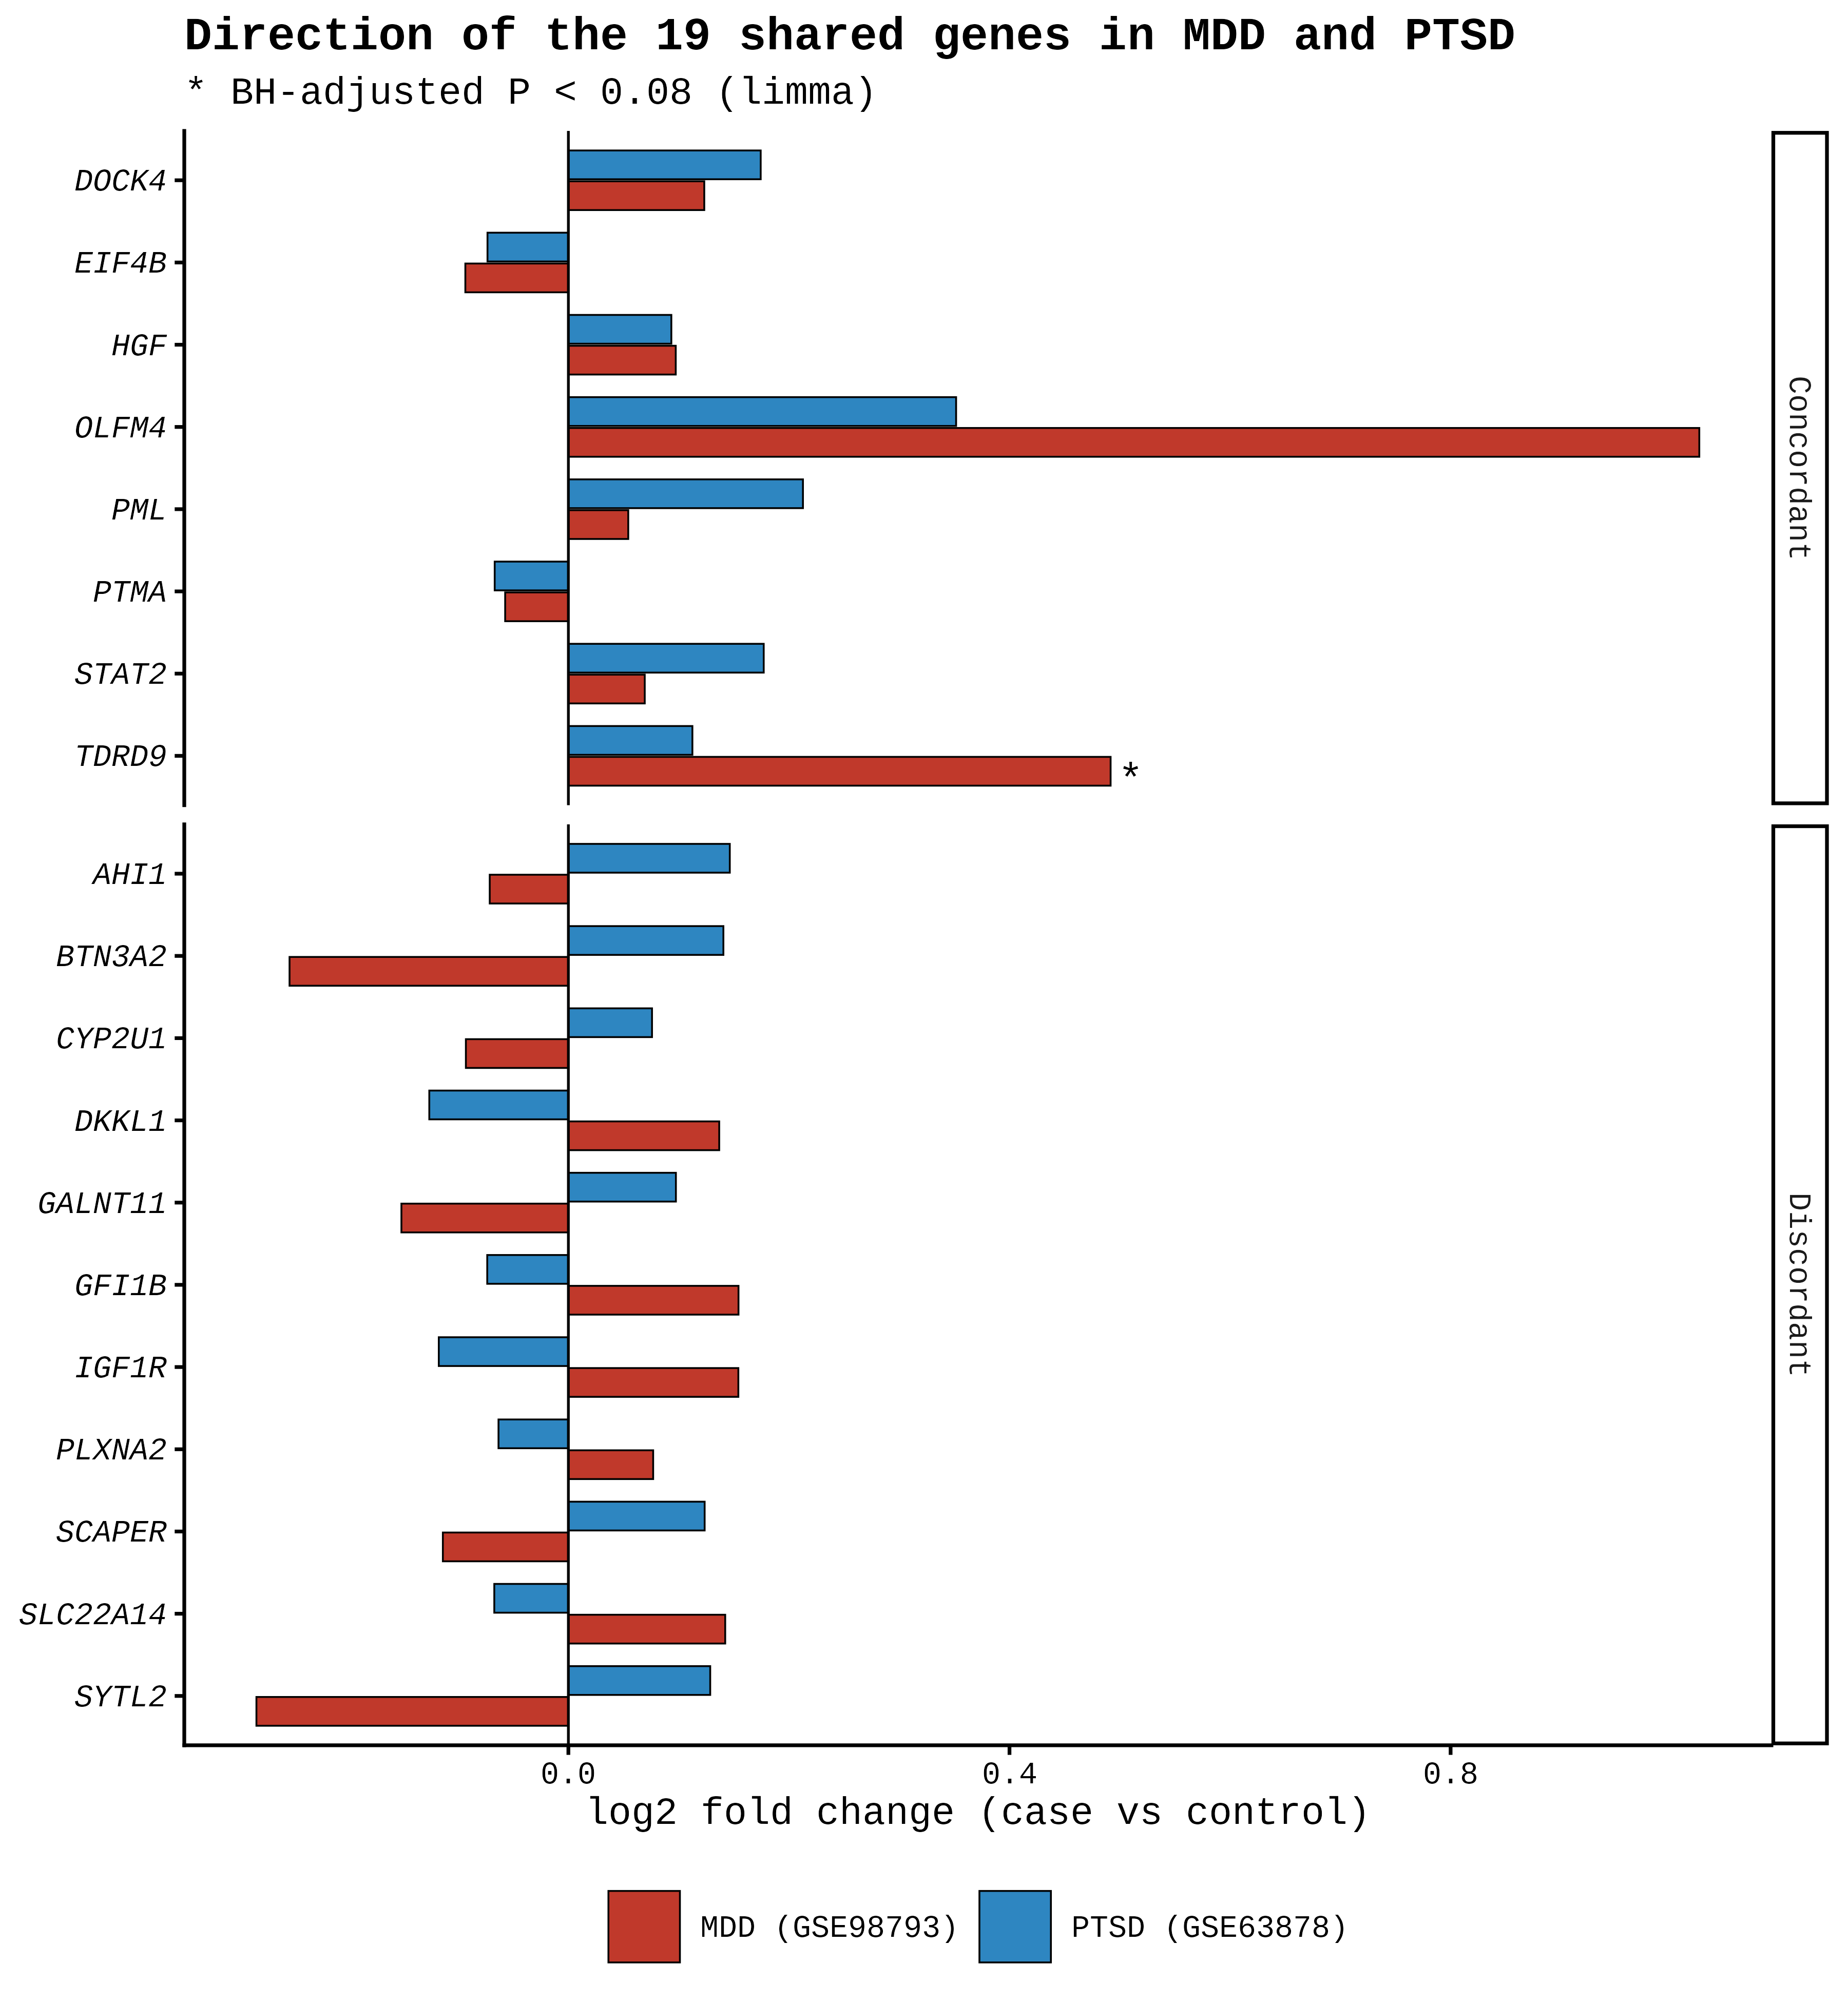

In [ ]:
R_CODE = r'''
options(stringsAsFactors = FALSE, warn = 1)
suppressPackageStartupMessages({ library(limma); library(data.table); library(ggplot2) })

ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT  <- paste0(ROOT, "SharedGenes_Reviewer10/"); dir.create(OUT, showWarnings = FALSE, recursive = TRUE)
SETS <- list(MDD  = list(gse = "GSE98793", full = paste0(ROOT, "Final_validation/GSE98793_matrix_Transpose_labeled.csv"),
                         score = paste0(ROOT, "process_datasets_0.08/score/GSE98793_matrix_Transpose_labeled_Fisher_Scores.csv")),
             PTSD = list(gse = "GSE63878", full = paste0(ROOT, "Final_validation/GSE63878_matrix_Transpose_labeled.csv"),
                         score = paste0(ROOT, "process_datasets_0.08/score/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv")))
SHARED <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R","GALNT11",
            "HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")
P_CUT <- 0.08; TOP_N <- 800

## gene-level matrix: probes averaged per gene symbol, log2 checked
gene_matrix <- function(path) {
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  y <- as.integer(df$target == 1)
  X <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X)); keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  M <- as.matrix(X[, keep]); sym <- sym[keep]
  if (max(M, na.rm = TRUE) > 50) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  list(G = G, y = y)
}

rows <- list()
for (dis in names(SETS)) {
  s <- SETS[[dis]]; g <- gene_matrix(s$full)
  grp <- factor(ifelse(g$y == 1, "case", "control"), levels = c("control", "case"))
  tt <- topTable(eBayes(lmFit(t(g$G), model.matrix(~ grp))), coef = 2, number = Inf, sort.by = "none", adjust.method = "BH")
  fs <- read.csv(s$score); fs <- fs[order(-fs$Fisher.Score), ]; fs$Rank <- seq_len(nrow(fs))
  cat(sprintf("%s (%s): %d genes; nominal p < %.2f: %d; BH-adjusted p < %.2f: %d\n",
              dis, s$gse, nrow(tt), P_CUT, sum(tt$P.Value < P_CUT), P_CUT, sum(tt$adj.P.Val < P_CUT)))
  for (gn in SHARED) {
    inT <- gn %in% rownames(tt); r <- match(gn, fs$Feature); lf <- if (inT) tt[gn, "logFC"] else NA
    rows[[length(rows) + 1]] <- data.frame(Gene = gn, Disorder = dis, Dataset = s$gse, log2FC = lf,
      P_value = if (inT) tt[gn, "P.Value"] else NA, adj_P = if (inT) tt[gn, "adj.P.Val"] else NA,
      Direction = ifelse(is.na(lf), NA, ifelse(lf > 0, "Up", "Down")),
      Fisher_score = if (!is.na(r)) fs$Fisher.Score[r] else NA, Fisher_rank = if (!is.na(r)) fs$Rank[r] else NA,
      Genes_ranked = nrow(fs))
  }
}
long <- do.call(rbind, rows); write.csv(long, paste0(OUT, "S19_shared_genes_long.csv"), row.names = FALSE)

w <- merge(long[long$Disorder == "MDD", ], long[long$Disorder == "PTSD", ], by = "Gene", suffixes = c("_MDD", "_PTSD"))
w <- w[match(SHARED, w$Gene), ]
w$Concordance <- ifelse(w$Direction_MDD == w$Direction_PTSD, "Concordant", "Discordant")
tab <- data.frame(Gene = w$Gene,
  `MDD log2FC` = round(w$log2FC_MDD, 3), `MDD P` = signif(w$P_value_MDD, 3), `MDD adj. P (BH)` = signif(w$adj_P_MDD, 3),
  `MDD direction` = w$Direction_MDD, `MDD Fisher rank` = paste0(w$Fisher_rank_MDD, "/", w$Genes_ranked_MDD),
  `PTSD log2FC` = round(w$log2FC_PTSD, 3), `PTSD P` = signif(w$P_value_PTSD, 3), `PTSD adj. P (BH)` = signif(w$adj_P_PTSD, 3),
  `PTSD direction` = w$Direction_PTSD, `PTSD Fisher rank` = paste0(w$Fisher_rank_PTSD, "/", w$Genes_ranked_PTSD),
  Concordance = w$Concordance, check.names = FALSE)
tab <- tab[order(tab$Concordance, tab$Gene), ]
write.csv(tab, paste0(OUT, "S19_Table_shared_genes.csv"), row.names = FALSE)

pd <- data.frame(Gene = factor(rep(w$Gene, 2), levels = rev(tab$Gene)),
                 Disorder = rep(c("MDD (GSE98793)", "PTSD (GSE63878)"), each = nrow(w)),
                 log2FC = c(w$log2FC_MDD, w$log2FC_PTSD), adjP = c(w$adj_P_MDD, w$adj_P_PTSD),
                 Concordance = rep(w$Concordance, 2))
pd$Sig <- ifelse(pd$adjP < P_CUT, "*", "")
p <- ggplot(pd, aes(log2FC, Gene, fill = Disorder)) +
  geom_col(position = position_dodge(0.75), width = 0.7, colour = "black", linewidth = 0.2) +
  geom_text(aes(label = Sig, hjust = ifelse(log2FC > 0, -0.3, 1.3)), position = position_dodge(0.75), size = 3.5, vjust = 0.75) +
  geom_vline(xintercept = 0, linewidth = 0.3) +
  scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  facet_grid(Concordance ~ ., scales = "free_y", space = "free_y") +
  labs(x = "log2 fold change (case vs control)", y = NULL,
       title = "Direction of the 19 shared genes in MDD and PTSD",
       subtitle = sprintf("* BH-adjusted P < %.2f (limma)", P_CUT)) +
  theme_classic(base_size = 9) +
  theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"), plot.title = element_text(face = "bold"))
for (ext in c("png", "tiff")) ggsave(paste0(OUT, "FigS6_shared_genes_log2FC.", ext), p, width = 6, height = 6.5, dpi = 600, bg = "white")
ggsave(paste0(OUT, "FigS6_shared_genes_log2FC.pdf"), p, width = 6, height = 6.5)

cat("\nConcordant:", sum(w$Concordance == "Concordant"), "| Discordant:", sum(w$Concordance == "Discordant"),
    "\nNominal P <", P_CUT, "in MDD:", sum(w$P_value_MDD < P_CUT, na.rm = TRUE), "| in PTSD:", sum(w$P_value_PTSD < P_CUT, na.rm = TRUE),
    "\nAdjusted P <", P_CUT, "in MDD:", sum(w$adj_P_MDD < P_CUT, na.rm = TRUE), "| in PTSD:", sum(w$adj_P_PTSD < P_CUT, na.rm = TRUE),
    "\nIn top", TOP_N, "MDD:", sum(w$Fisher_rank_MDD <= TOP_N, na.rm = TRUE), "| PTSD:", sum(w$Fisher_rank_PTSD <= TOP_N, na.rm = TRUE), "\n")
'''
open("/content/shared_genes_r10.R", "w").write(R_CODE)

import subprocess, sys, pandas as pd
from IPython.display import display, Image
proc = subprocess.Popen(["Rscript", "/content/shared_genes_r10.R"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout: sys.stdout.write(line)
proc.wait(); print("exit code:", proc.returncode)

OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/SharedGenes_Reviewer10/"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
display(pd.read_csv(OUT + "S19_Table_shared_genes.csv"))
display(Image(OUT + "FigS6_shared_genes_log2FC.png", width=600))